# Trabajo Práctico 1 - Ciencia de Datos (2026) - Mantenimiento Predictivo Industrial

## Parte 1: Análisis Exploratorio de Datos (EDA)
En esta parte, se realiza el análisis exploratorio de los datos para comprender su estructura, identificar patrones, detectar valores atípicos y evaluar la calidad de los datos. Para esto, se realizan diversos cálculos cuyos resultados se presentan principalmente en formato de tablas y gráficos.

### Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os

### Carga del conjunto de datos

In [2]:
filepath = os.path.join('.', 'data', 'raw', 'i40 (datos).csv')
df = pd.read_csv(filepath)
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 14521 filas x 9 columnas


,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


**Observaciones**: 
- El dataset contiene 14521 filas y 9 columnas.
- Probablemente tanto la columna idx como parent_device_id no aporten información relevante para el análisis, por lo que podrían ser descartados para simplificar el trabajo.
- Además de la columna de la etiqueta (target), la única columna categórica relevante es product_type.

### Visualizar información general del dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  str    
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  str    
dtypes: float64(3), int64(4), str(2)
memory usage: 1021.1 KB


**Podemos observar entonces que cada columna es del siguiente tipo de dato:**
- 0   idx                 : Categorico Nominal
- 1   parent_device_id    : Categorico Nominal
- 2   product_type        : Categorico Nominal (en etapas posteriores hay un análisis sobre esta conclusión)
- 3   air_temp [K]        : Numérico Continuo
- 4   process_temp [K]    : Numérico Continuo
- 5   speed [RPM]         : Numérico Discreto
- 6   torque [Nm]         : Numérico Continuo
- 7   tool_wear [min]     : Numérico Discreto
- 8   target              : Categórico Ordinal

**Observaciones**: 
- La columna air_temp [K] tiene solo 14481 valores no nulos respecto al total de 14521, lo que indica que hay 40 filas con valores faltantes en esta columna.

### Medidas de Tendencia Central y Distribución de las Variables

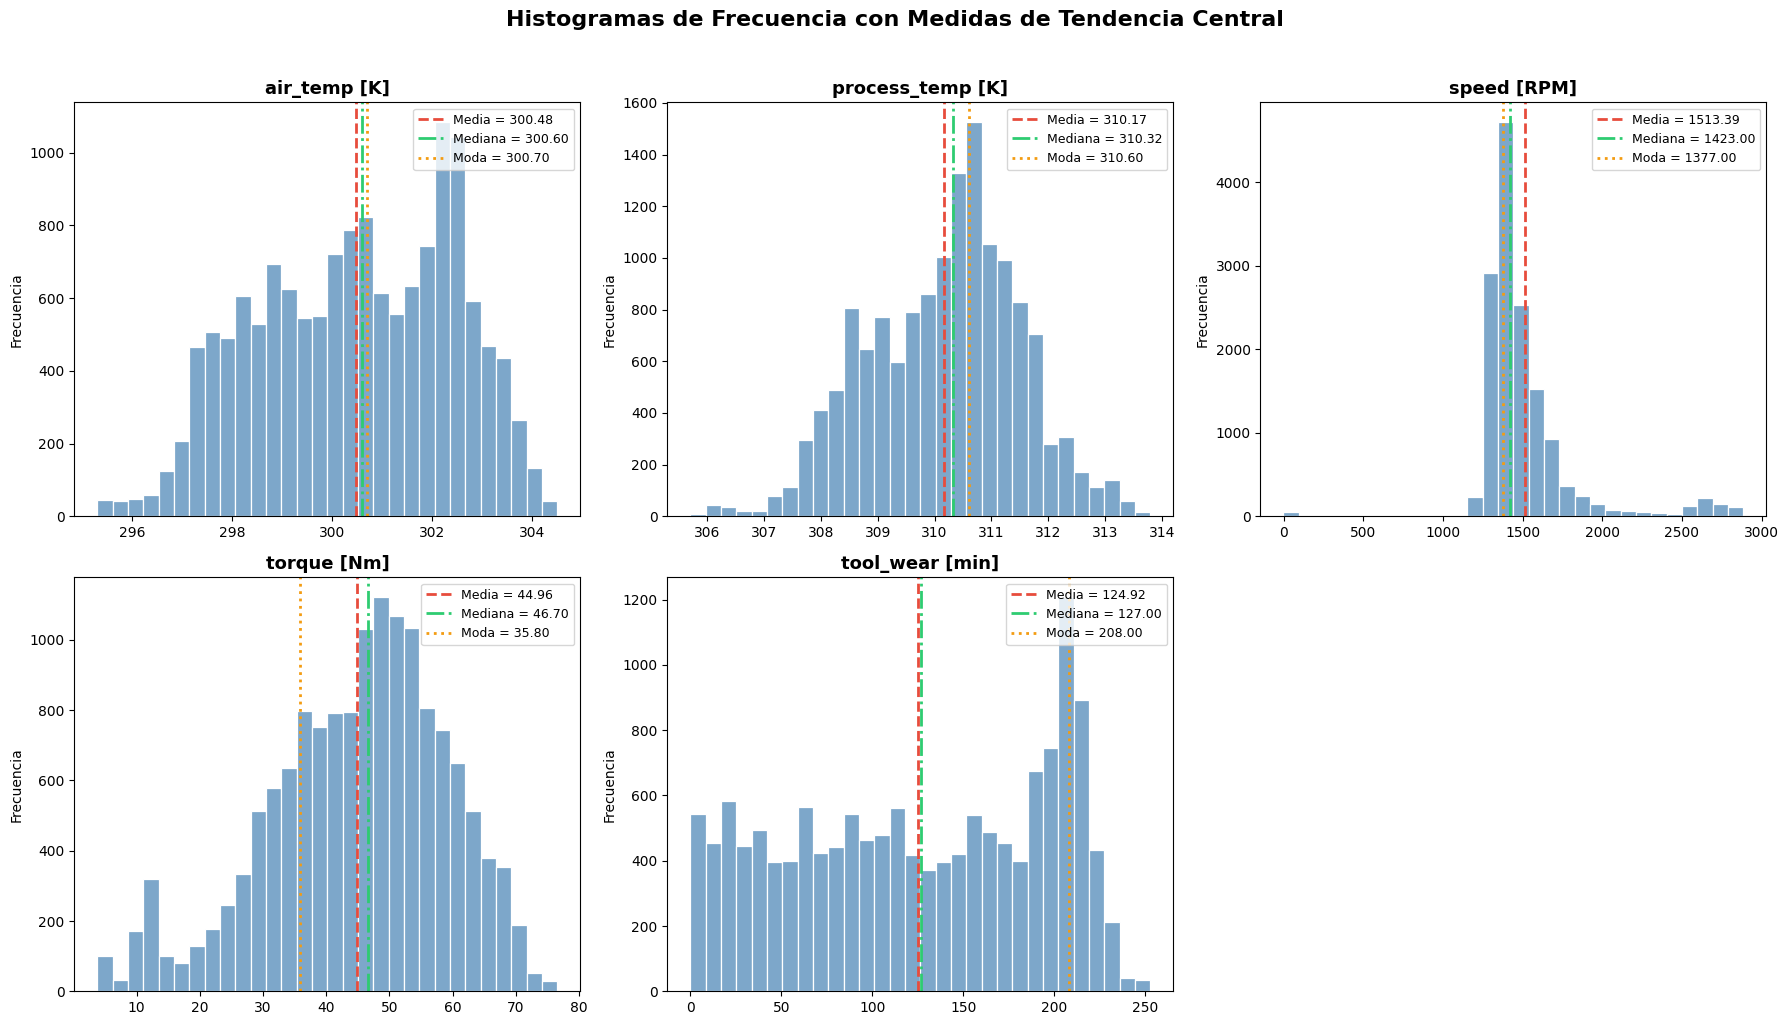

In [4]:
# Columnas numéricas relevantes (excluimos idx y parent_device_id)
columnas_numericas = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]

    # Histograma (frecuencia absoluta)
    sns.histplot(x = df[col], bins=30, kde=False, color='steelblue', edgecolor='white',
                 alpha=0.7, ax=ax, stat='count')

    # Cálculo de medidas de tendencia central
    media   = df[col].mean()
    mediana = df[col].median()
    moda    = df[col].mode()[0]

    ax.axvline(media,   color='#e74c3c', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
    ax.axvline(mediana, color='#2ecc71', linestyle='-.',  linewidth=2, label=f'Mediana = {mediana:.2f}')
    ax.axvline(moda,    color='#f39c12', linestyle=':',   linewidth=2, label=f'Moda = {moda:.2f}')

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_visible(False)

fig.suptitle('Histogramas de Frecuencia con Medidas de Tendencia Central', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- Las columnas air_temp [K], process_temp [K] y torque [Nm] presentan distribuciones que parecen ser aproximadamente normales.
- Por otro lado, las columnas speed [RPM] y tool_wear [min] parecieran seguir alguna otra distribución. Incluso pareciendo una distribución exponencial en Speed [RPM] si quitamos el outlier de la izquierda

### Medidas de Dispersión

### Proporciones de las Columnas Categóricas

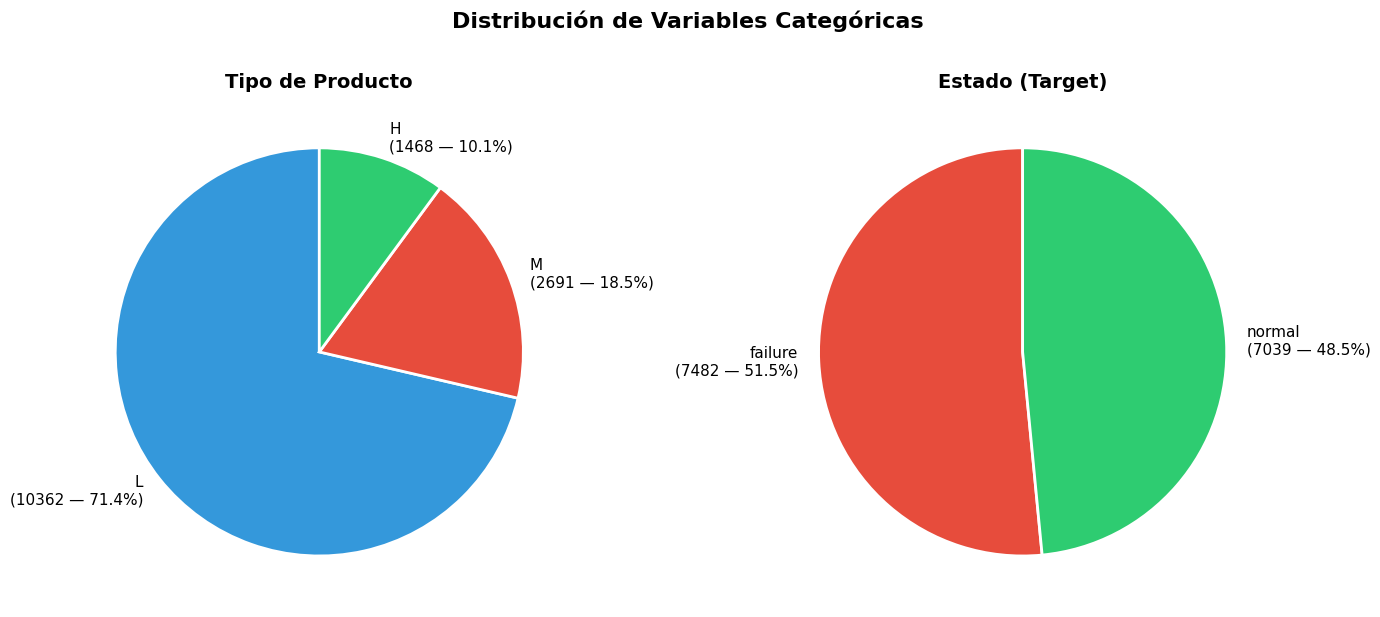

In [5]:
columnas_categoricas = ['product_type', 'target']
titulos = ['Tipo de Producto', 'Estado (Target)']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

paletas = [
    ['#3498db', '#e74c3c', '#2ecc71'],   # product_type: L, M, H
    ['#e74c3c', '#2ecc71']               # target: failure, normal
]

for i, col in enumerate(columnas_categoricas):
    ax = axes[i]
    conteos = df[col].value_counts()
    proporciones = conteos / conteos.sum() * 100

    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos.index, conteos.values, proporciones.values)]

    wedges, texts = ax.pie(
        conteos.values,
        labels=etiquetas,
        colors=paletas[i],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    for t in texts: t.set_fontsize(11)

    ax.set_title(titulos[i], fontsize=14, fontweight='bold')

fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- Con la proporción de la columna target (Estado), se puede observar que el dataset está ligeramente desbalanceado. Sabiendo esto, se podrían aplicar técnicas de balanceo de clases en etapas posteriores del análisis para mejorar el rendimiento de los modelos predictivos. Sin embargo, también hay que considerar la posibilidad de no balancear en absoluto, dado que:
    - La diferencia de proporción es mínima.
    - En teoría, cuando hay desbalanceo de clases, los modelos tienen a dar mejores resultados en la clase mayoritaria, lo que podría ser beneficioso en este caso ya que el objetivo es predecir si hay una fallas en las máquinas. De esta manera, bajo este escenario puede ser preferible tener un falso positivo (predecir una falla que no es) antes que un falso negativo (predecir no falla cuando fue falla).

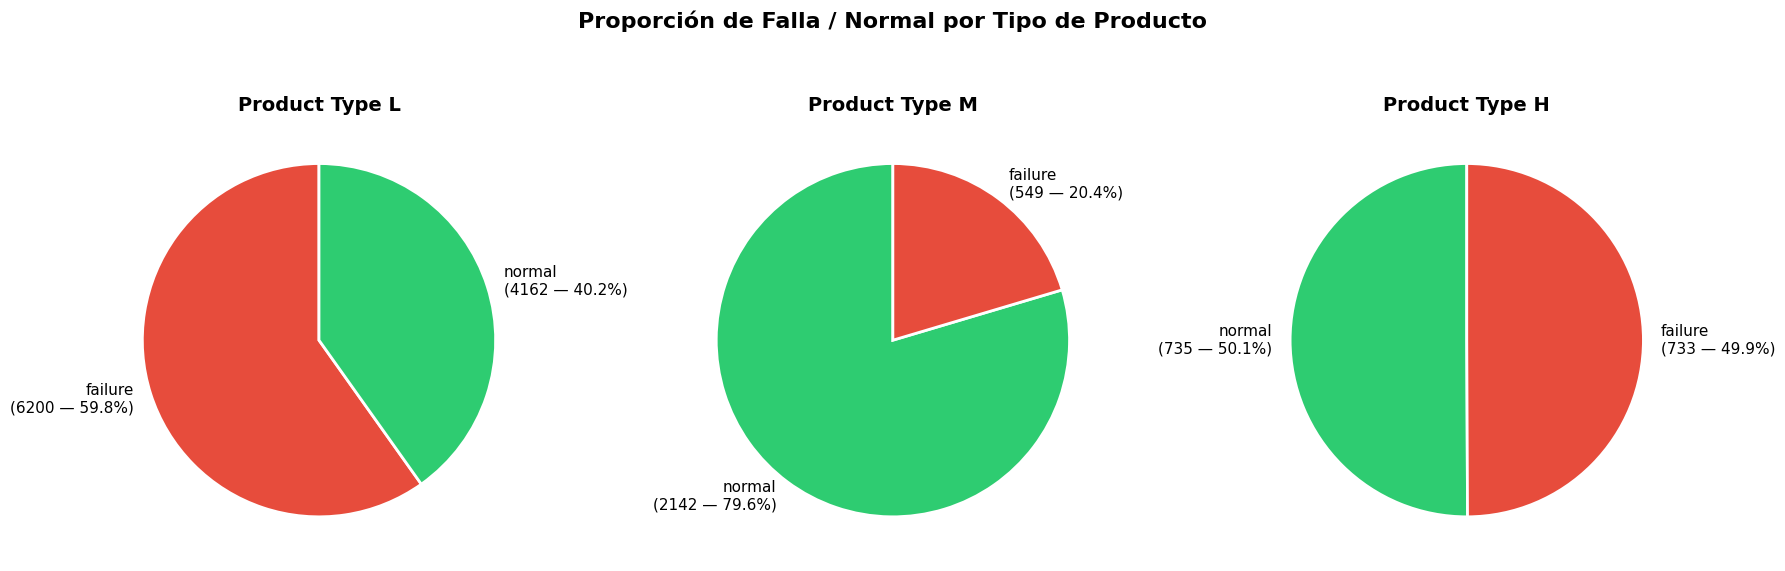

In [6]:
tipos_producto = ['L', 'M', 'H']
color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, prod in enumerate(tipos_producto):
    ax = axes[i]
    conteos = df.loc[df['product_type'] == prod, 'target'].value_counts()
    proporciones = conteos / conteos.sum() * 100

    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos.index, conteos.values, proporciones.values)]
    
    colores_pie = [color_map[idx] for idx in conteos.index]

    wedges, texts = ax.pie(
        conteos.values,
        labels=etiquetas,
        colors=colores_pie,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    for t in texts:
        t.set_fontsize(11)

    ax.set_title(f'Product Type {prod}', fontsize=14, fontweight='bold')

fig.suptitle('Proporción de Falla / Normal por Tipo de Producto', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- La proporciones para product_type "L" presenta la proporción más alta de fallas, cercana al 60%, lo cual podría indicar que este tipo de producto es particularmente susceptible a fallas (quiza este tipo de producto es más vulnerable al proceso productivo). 
- El tipo de producto "H" muestra proporciones inusualmente equilibradas entre "normal" y "failure" (cercanas al 50/50), lo cual resulta llamativo dado que, en condiciones normales de operación, las fallas suelen representar una proporción significativamente menor. 
- Por otro lado, la proporción para product_type "M" indica que solo el 20% de los productos del tipo M tienen una falla, lo que podría sugerir que el tipo de producto M es menos propenso a fallas en comparación con los tipos L y H, tal vez por características específicas de ese tipo de producto o por condiciones de operación particulares.


Es raro que H tenga proporciones iguales y L tenga un 60% de fallas, porque teóricamente siempre las fallas deberían ser mucho menor al normal, **esto intuye que el tipo de producto influye directamente en la probabilidad de falla**. Es un punto de interés importante para investigar en etapas posteriores del trabajo.



### Diagramas de Caja (Box Plots)

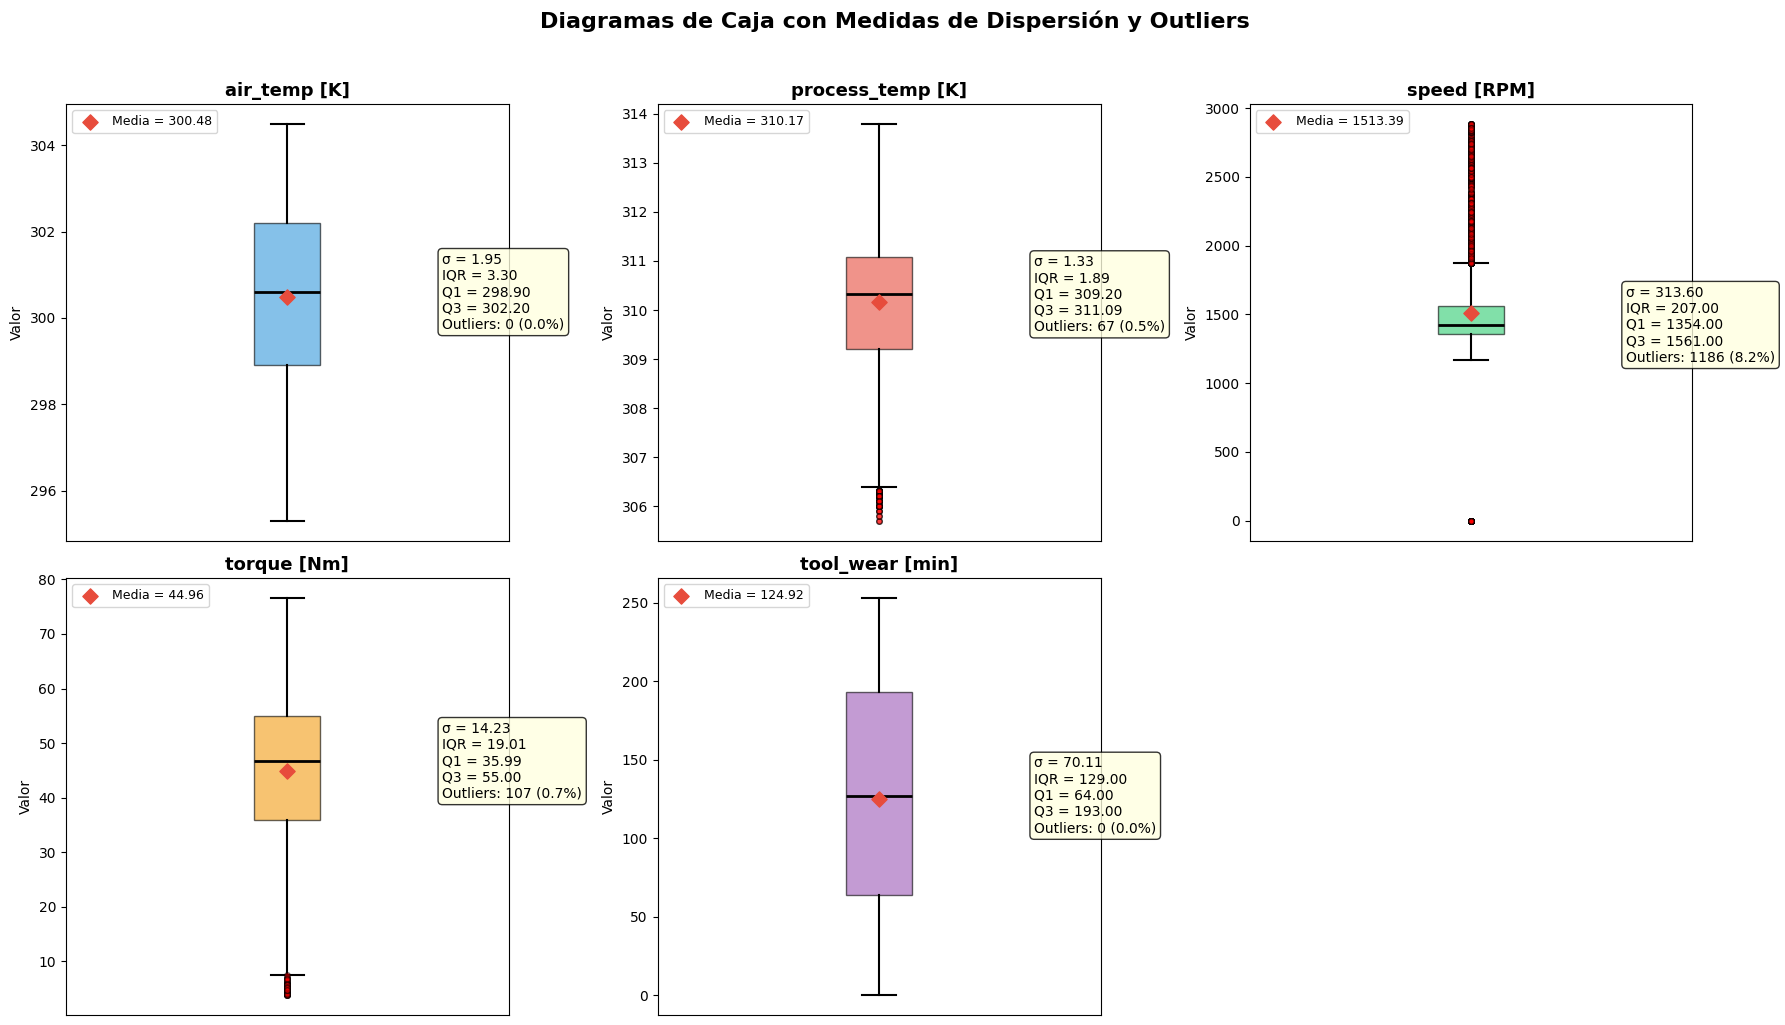

In [7]:
# Box Plots para cada variable numérica

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

colores_box = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, col in enumerate(columnas_numericas):
    df_sin_nulos = df[col].dropna()
    
    ax = axes[i]

    bp = ax.boxplot(df_sin_nulos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colores_box[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

    media   = df_sin_nulos.mean()
    std     = df_sin_nulos.std()
    mediana = df_sin_nulos.median()
    q1      = df_sin_nulos.quantile(0.25)
    q3      = df_sin_nulos.quantile(0.75)
    iqr     = q3 - q1

    # Contar outliers con método IQR: valores fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    n_out   = ((df_sin_nulos < lim_inf) | (df_sin_nulos > lim_sup)).sum()
    pct_out = n_out / len(df_sin_nulos) * 100

    ax.scatter([1], [media], marker='D', color='#e74c3c', s=60, zorder=5, label=f'Media = {media:.2f}')

    stats_text = (f'σ = {std:.2f}\n'
                  f'IQR = {iqr:.2f}\n'
                  f'Q1 = {q1:.2f}\n'
                  f'Q3 = {q3:.2f}\n'
                  f'Outliers: {n_out} ({pct_out:.1f}%)')
    ax.text(1.35, mediana, stats_text, fontsize=10, va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xticks([])
    ax.legend(fontsize=9, loc='upper left')

axes[-1].set_visible(False)

fig.suptitle('Diagramas de Caja con Medidas de Dispersión y Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

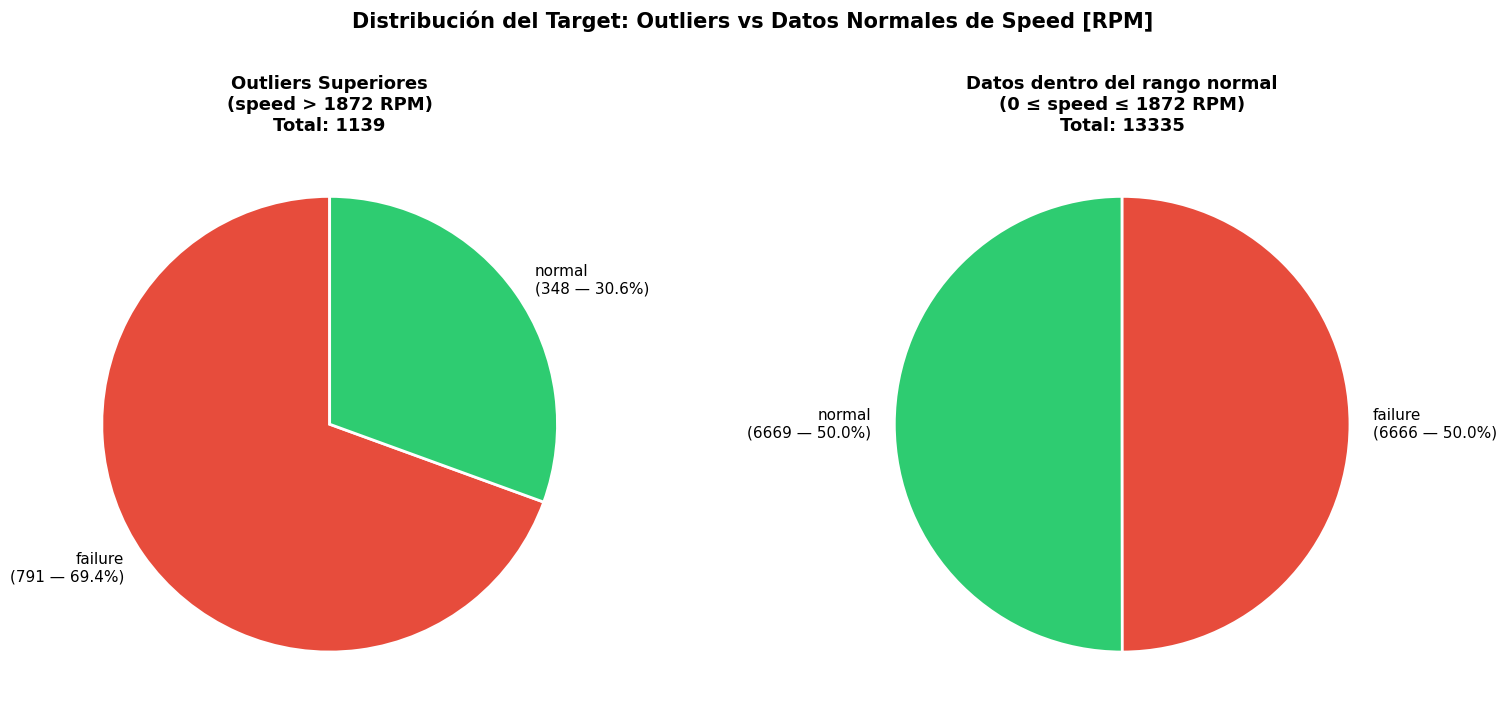

In [8]:
# Detección de outliers superiores en speed [RPM] usando el método IQR
Q1 = df['speed [RPM]'].quantile(0.25)
Q3 = df['speed [RPM]'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

datos_validos = df[df['speed [RPM]'] >= 0]  # Excluir valores -1

outliers_speed = datos_validos[datos_validos['speed [RPM]'] > limite_superior]
no_outliers_speed = datos_validos[datos_validos['speed [RPM]'] <= limite_superior]

color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

# Gráfico 1: Outliers superiores
conteos_out = outliers_speed['target'].value_counts()
proporciones_out = conteos_out / conteos_out.sum() * 100

etiquetas_out = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos_out.index, conteos_out.values, proporciones_out.values)]
colores_out = [color_map[idx] for idx in conteos_out.index]

wedges1, texts1 = axes[0].pie(
    conteos_out.values,
    labels=etiquetas_out,
    colors=colores_out,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in texts1:
    t.set_fontsize(11)

axes[0].set_title(
    f'Outliers Superiores\n(speed > {limite_superior:.0f} RPM)\n'
    f'Total: {len(outliers_speed)}',
    fontsize=13, fontweight='bold'
)

# Gráfico 2: Datos dentro del rango normal
conteos_no = no_outliers_speed['target'].value_counts()
proporciones_no = conteos_no / conteos_no.sum() * 100

etiquetas_no = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                in zip(conteos_no.index, conteos_no.values, proporciones_no.values)]
colores_no = [color_map[idx] for idx in conteos_no.index]

wedges2, texts2 = axes[1].pie(
    conteos_no.values,
    labels=etiquetas_no,
    colors=colores_no,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in texts2:
    t.set_fontsize(11)

axes[1].set_title(
    f'Datos dentro del rango normal\n(0 ≤ speed ≤ {limite_superior:.0f} RPM)\n'
    f'Total: {len(no_outliers_speed)}',
    fontsize=13, fontweight='bold'
)

fig.suptitle(
    'Distribución del Target: Outliers vs Datos Normales de Speed [RPM]',
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()


**Observaciones:**

Se excluyen del análisis los valores atípicos inferiores de speed [RPM] dado que corresponden a registros con valor -1, los cuales representan datos faltantes que serán imputados en etapas posteriores (10 registros en total).

De los 1139 registros identificados como outliers superiores (velocidades por encima del límite del boxplot), el **69.4% (791) presentan fallas**, frente al aproximadamente 50% que se observa en los 13335 registros dentro del rango normal. Esta diferencia de casi 20 puntos porcentuales es **considerable dado el tamaño de la muestra**.

Esto sugiere que **las velocidades atípicamente altas tienen una incidencia directa y significativa en la ocurrencia de fallas**, lo cual es esperado en un contexto de mantenimiento predictivo industrial, donde velocidades excesivas generan mayor desgaste, vibración y estrés mecánico.

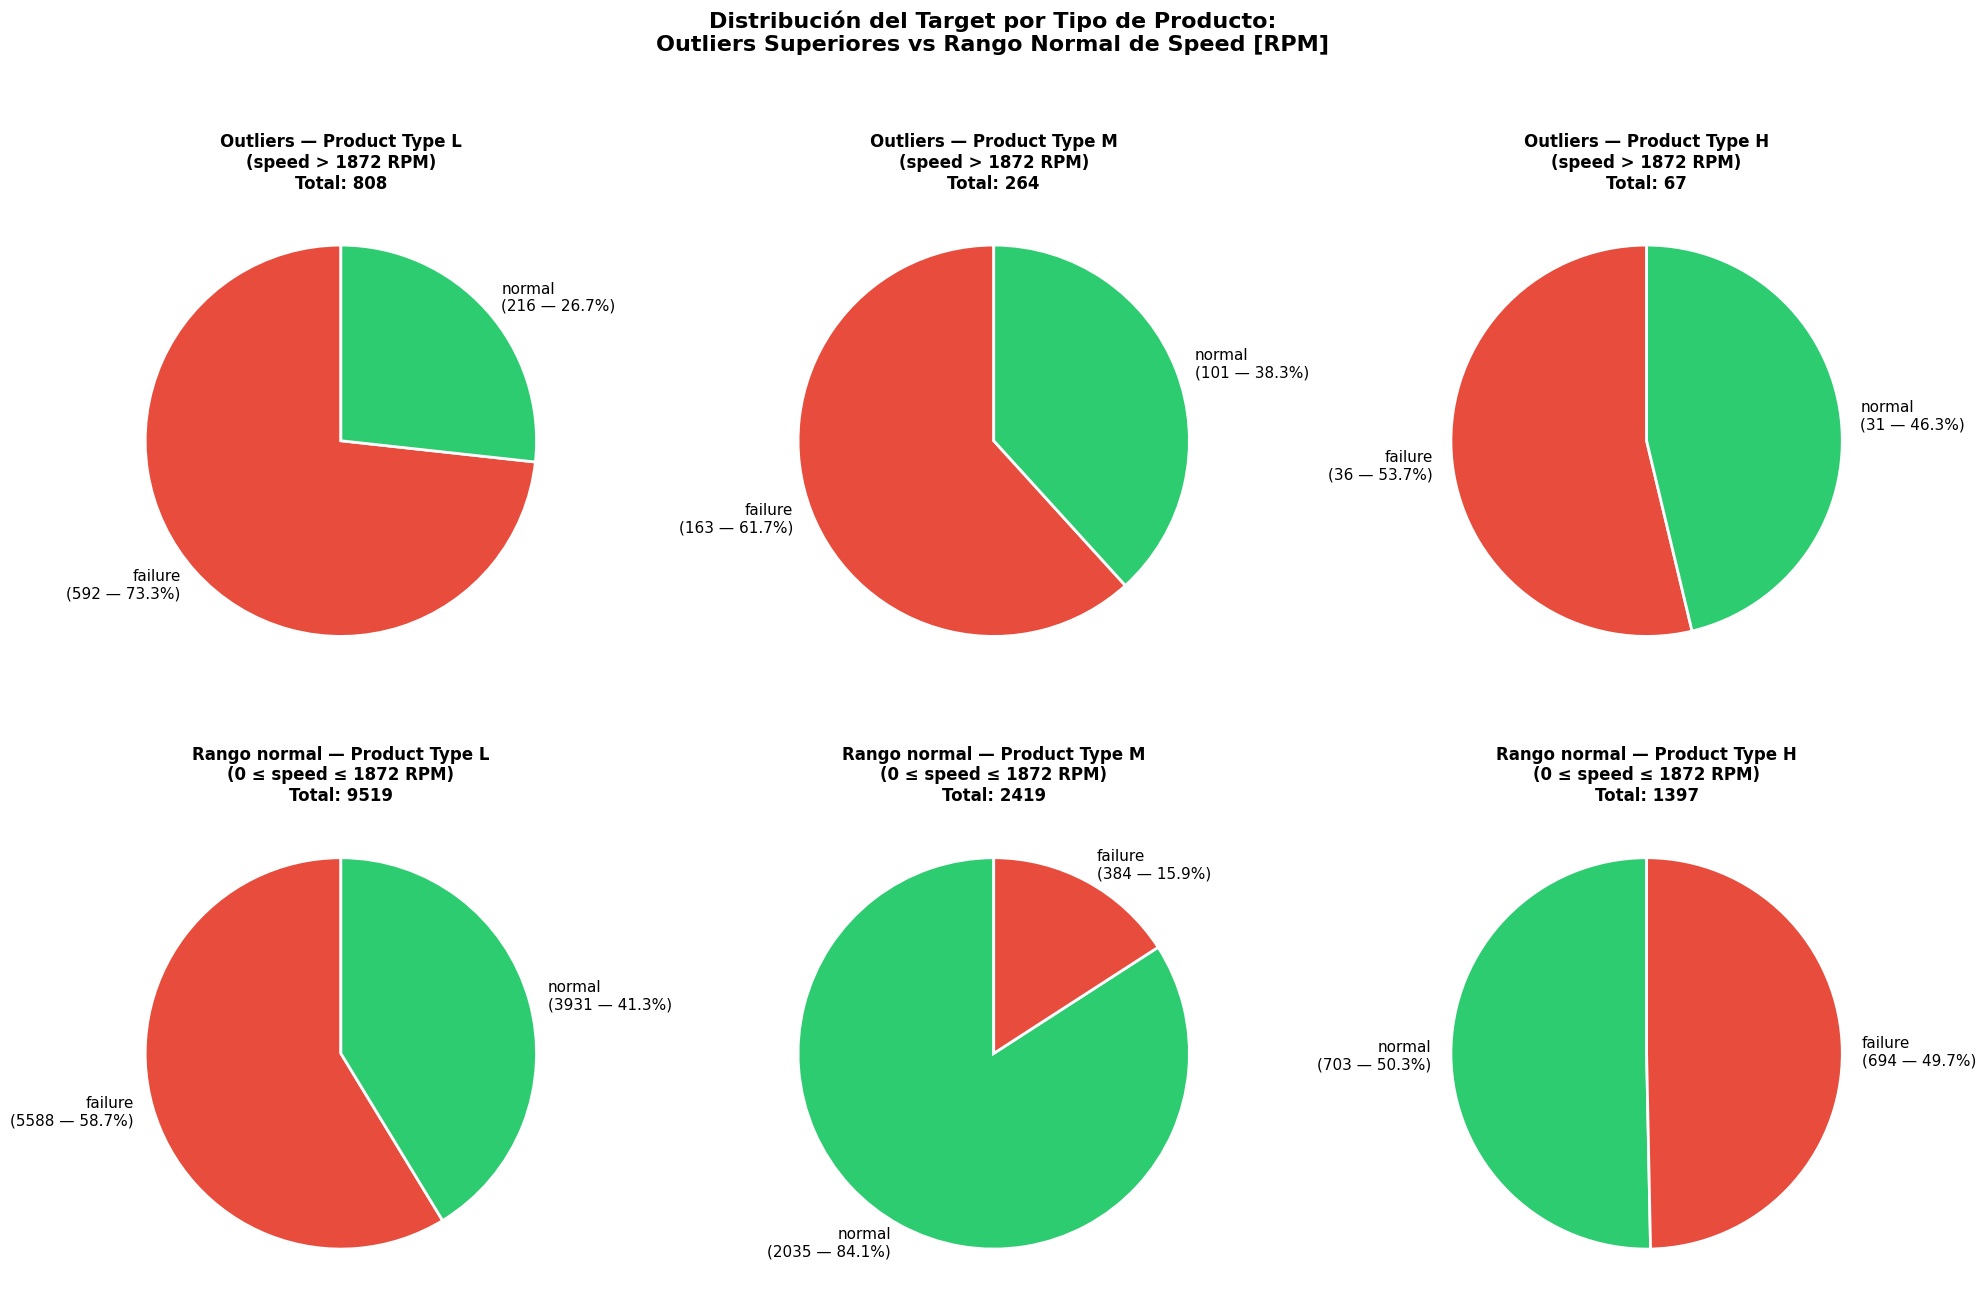

In [9]:
Q1 = df['speed [RPM]'].quantile(0.25)
Q3 = df['speed [RPM]'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

datos_validos = df[df['speed [RPM]'] >= 0]
outliers_speed = datos_validos[datos_validos['speed [RPM]'] > limite_superior]
no_outliers_speed = datos_validos[datos_validos['speed [RPM]'] <= limite_superior]

tipos_producto = ['L', 'M', 'H']
color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 13))

for i, pt in enumerate(tipos_producto):
    # Fila 1: Outliers superiores por tipo de producto
    subset_out = outliers_speed[outliers_speed['product_type'] == pt]

    if len(subset_out) > 0:
        conteos_out = subset_out['target'].value_counts()
        proporciones_out = conteos_out / conteos_out.sum() * 100

        etiquetas_out = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                         in zip(conteos_out.index, conteos_out.values, proporciones_out.values)]
        colores_out = [color_map[idx] for idx in conteos_out.index]

        wedges, texts = axes[0][i].pie(
            conteos_out.values,
            labels=etiquetas_out,
            colors=colores_out,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for t in texts:
            t.set_fontsize(11)
    else:
        axes[0][i].text(0.5, 0.5, 'Sin outliers', ha='center', va='center', fontsize=12)

    axes[0][i].set_title(
        f'Outliers — Product Type {pt}\n(speed > {limite_superior:.0f} RPM)\nTotal: {len(subset_out)}',
        fontsize=12, fontweight='bold'
    )

    # Fila 2: Datos normales por tipo de producto
    subset_no = no_outliers_speed[no_outliers_speed['product_type'] == pt]

    if len(subset_no) > 0:
        conteos_no = subset_no['target'].value_counts()
        proporciones_no = conteos_no / conteos_no.sum() * 100

        etiquetas_no = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                        in zip(conteos_no.index, conteos_no.values, proporciones_no.values)]
        colores_no = [color_map[idx] for idx in conteos_no.index]

        wedges2, texts2 = axes[1][i].pie(
            conteos_no.values,
            labels=etiquetas_no,
            colors=colores_no,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for t in texts2:
            t.set_fontsize(11)
    else:
        axes[1][i].text(0.5, 0.5, 'Sin datos', ha='center', va='center', fontsize=12)

    axes[1][i].set_title(
        f'Rango normal — Product Type {pt}\n(0 ≤ speed ≤ {limite_superior:.0f} RPM)\nTotal: {len(subset_no)}',
        fontsize=12, fontweight='bold'
    )

fig.suptitle(
    'Distribución del Target por Tipo de Producto:\nOutliers Superiores vs Rango Normal de Speed [RPM]',
    fontsize=16, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

### **Observaciones**:
Al desagregar el análisis por tipo de producto, se revelan patrones que refuerzan la hipótesis de que las categorías L, M y H representan niveles de calidad (Low, Medium, High) de los productos utilizados:

**Producto tipo L (Low / Baja calidad):**
- En el rango normal de velocidades ya presenta una tasa de fallas muy alta (58.7%), la más elevada de los tres tipos.
- Al operar a velocidades atípicamente altas, la tasa de fallas asciende al 73.3% (+14.6 puntos porcentuales).
- Además, concentra la mayor cantidad de outliers (808 de 1139, es decir, el 70.9%), lo cual sugiere que los productos de baja calidad no solo fallan más, sino que también tienden a operar fuera de los rangos normales con mayor frecuencia.
- Este comportamiento es consistente con un producto de baja calidad ya que inherentemente es más propenso a fallar en cualquier condición y tiene mayor degradación a velocidades extremas.

**Producto tipo M (Medium / Calidad media):**
- En condiciones normales de velocidad presenta la tasa de fallas más baja de los tres tipos, con apenas un 15.9%. Esto indica un producto confiable cuando opera dentro de sus parámetros de diseño.
- Sin embargo, al operar a velocidades atípicas, la tasa de fallas se dispara al 61.7%, un incremento de casi 46 puntos porcentuales, el salto más drástico de los tres tipos.
- Esto es consistente con un producto de calidad intermedia ya que fue bien diseñado para condiciones normales de operación, pero se degrada cuando se lo somete a condiciones extremas para las que no fue dimensionado.

**Producto tipo H (High / Alta calidad / Dureza alta):**
- En el rango normal de velocidades presenta una tasa de fallas de aproximadamente 50%, similar a la observada en los análisis previos.
- Al operar a velocidades atípicas, la tasa apenas sube al 53.7% (+4 puntos porcentuales), la variación más pequeña de los tres tipos.
- Si bien la cantidad de outliers es reducida (67), este patrón sugiere que los productos de alta calidad son los más resistentes a la degradación por velocidades extremas, ya que su tasa de fallas prácticamente no varía al operar fuera del rango normal.
- No obstante, su tasa de fallas base de ~50% (ya observada y señalada como anómala en análisis previos) podría deberse a otros factores de falla no relacionados con la velocidad, lo cual requiere investigación adicional.

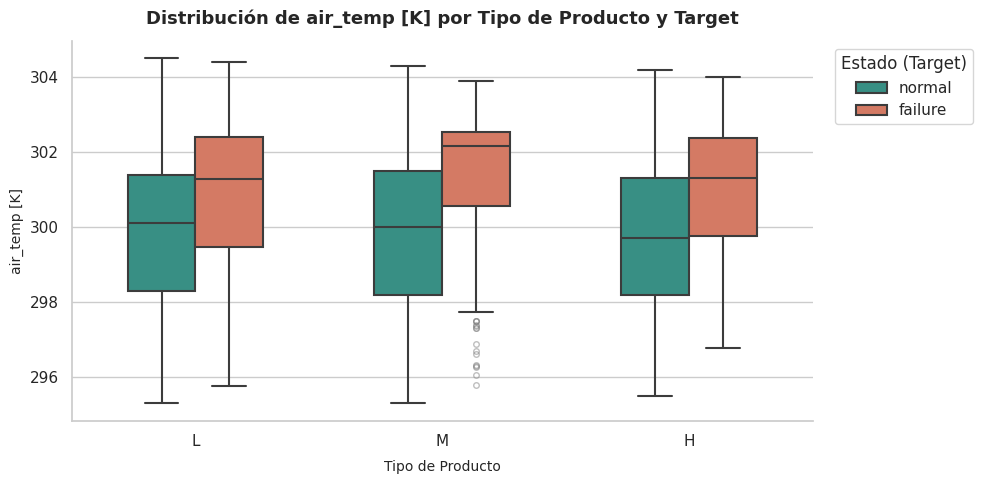

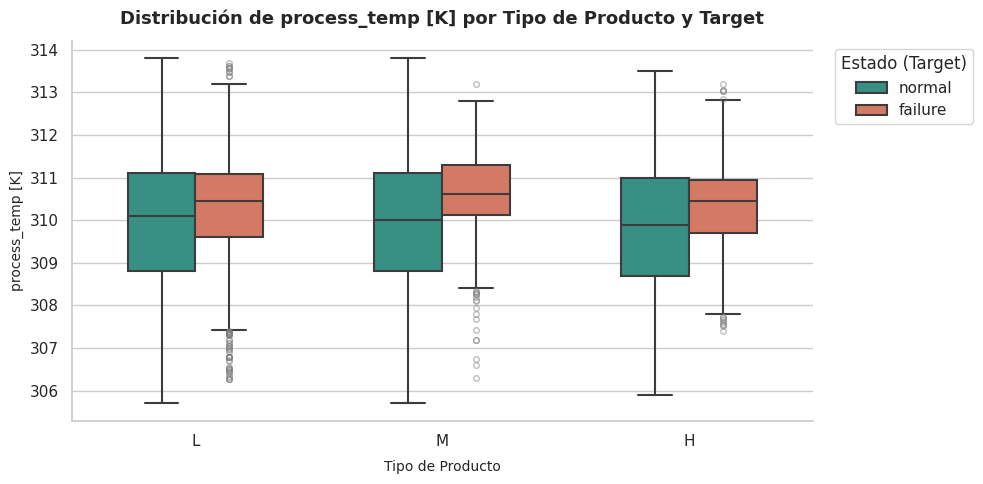

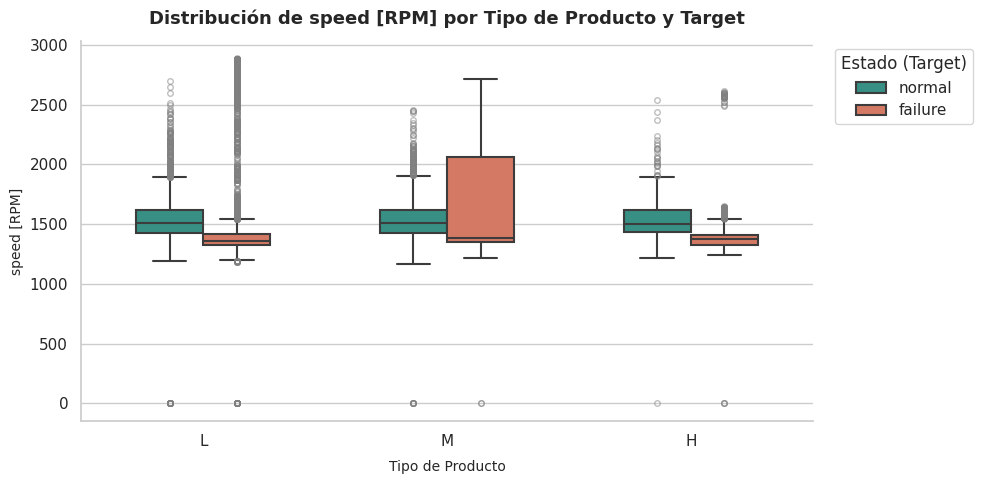

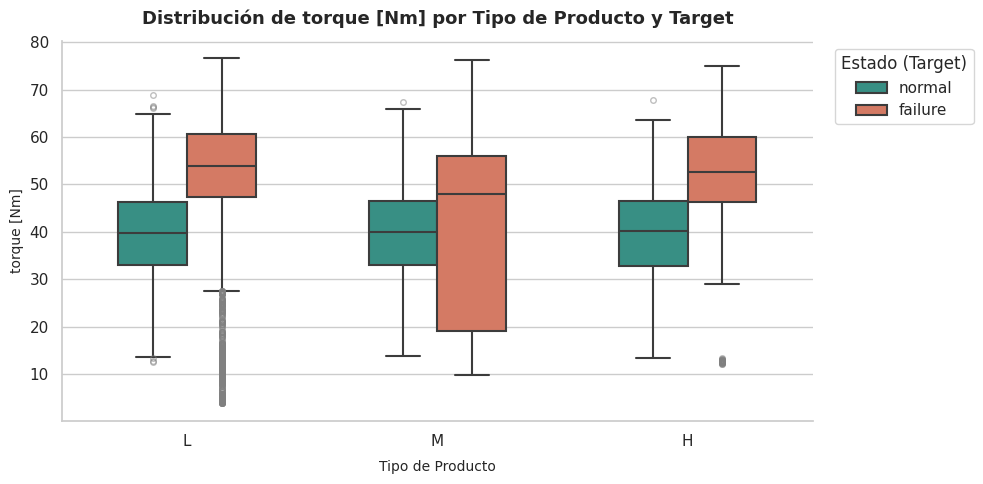

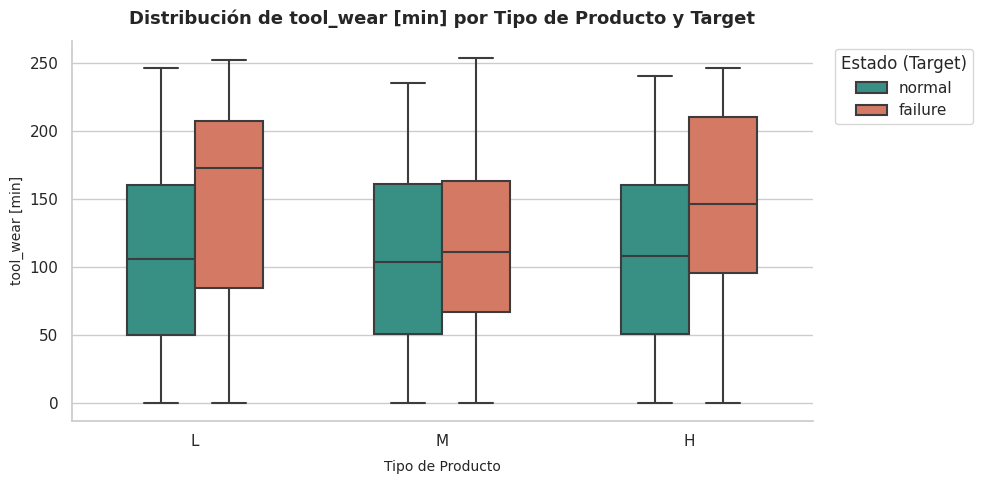

In [10]:
variables_numericas = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
palette_colors = {'normal': '#2a9d8f', 'failure': '#e76f51'}

sns.set_theme(style="whitegrid")

for var in variables_numericas:
    plt.figure(figsize=(10, 5))
    
    sns.boxplot(
        data=df,
        x='product_type',
        y=var,
        hue='target',
        order=['L', 'M', 'H'],
        hue_order=['normal', 'failure'],
        palette=palette_colors,
        width=0.55,
        linewidth=1.5,
        fliersize=4,
        flierprops={'marker': 'o', 'markeredgecolor': 'gray', 'alpha': 0.5}
    )
    
    plt.title(f'Distribución de {var} por Tipo de Producto y Target', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Tipo de Producto', fontsize=10, labelpad=8)
    plt.ylabel(var, fontsize=10)
    
    plt.legend(title='Estado (Target)', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    sns.despine()
    
    plt.tight_layout()
    plt.show()

### Análisis Comparativo de Distribuciones Numéricas por Tipo de Producto (L, M, H)

Para comprender el comportamiento operativo y los modos de falla de cada tipo de producto, se analizaron los gráficos de caja de las variables físicas numéricas segmentados por la variable objetivo (target). 

#### Comportamiento y Hallazgos por Variable Física

##### A. Perfiles Térmicos (air_temp [K] y process_temp [K])
* En los tres tipos de producto (**L, M y H**), las instancias clasificadas como `failure` se concentran en **rangos de temperatura (tanto ambiental como del proceso) superiores** en comparación con el estado `normal`.
* Esto aporta evidencia sobre la presencia del modo de falla por **Disipación Térmica (HDF - *Heat Dissipation Failure*)** como un fenómeno transversal, donde el sobrecalentamiento actúa como detonante del fallo independientemente de la robustez del material.

##### B. Dinámica de Operación (speed [RPM] y torque [Nm])
* **Tipos L y H:** Presentan un comportamiento operativo normal muy acotado (velocidad en torno a 1500 RPM y torque en 40 Nm). En situaciones de falla, muestran una clara polarización:
  * Fallas por sobrecarga en baja velocidad y alto torque (fatiga mecánica).
  * Caídas abruptas de torque a valores inferiores a ~15 Nm acompañadas de altas revoluciones, lo cual se alinea con roturas mecánicas  instantáneas por pérdida repentina de carga.
* **Tipo M:** Las fallas exhiben un comportamiento mucho más disperso. El rango de velocidad de falla abarca desde 1300 hasta 2000 RPM, y el torque de falla se extiende ampliamente entre 20 y 55 Nm, evidenciando que la calidad M experimenta fallas en regímenes intermedios no necesariamente extremos.

##### C. Desgaste de Herramienta (tool_wear [min])
* **Tipos L y H:** Muestran una progresión ordinal lógica esperada. En estado `normal`, la mediana de desgaste se sitúa cercana a los 100 minutos, mientras que en estado de `failure`, la mediana asciende considerablemente (superando los 150 min para L y los 170 min para H). Esto convalida el modo de falla por **Desgaste de Herramienta (TWF - *Tool Wear Failure*)** por envejecimiento.
* **Tipo M:** En esta calidad, la distribución del desgaste de la herramienta es **prácticamente idéntica entre los estados `normal` y `failure`** (ambas medianas convergen en torno a los 110 minutos). Esto es una **anomalía**.
  * Este hallazgo revela que **el Tipo M rara vez experimenta fallas por desgaste físico acumulado**. Las herramientas de tipo M tienden a fallar de forma prematura debido a factores operacionales dinámicos (picos de torque o fluctuaciones de velocidad) antes de alcanzar un desgaste temporal avanzado.

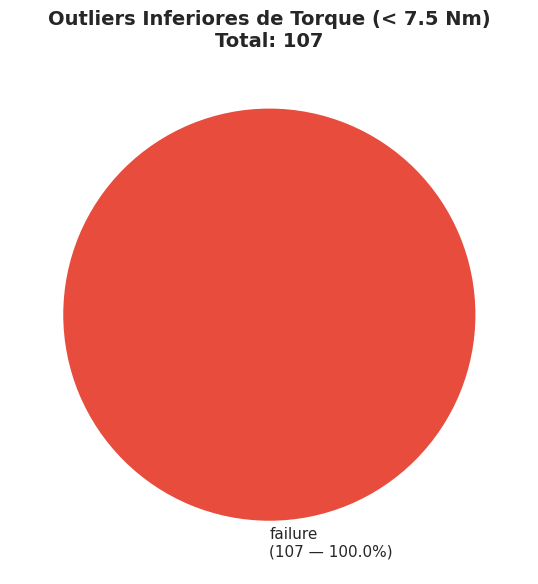

In [11]:
# Detección de outliers inferiores en torque [Nm]
Q1_torque = df['torque [Nm]'].quantile(0.25)
Q3_torque = df['torque [Nm]'].quantile(0.75)
IQR_torque = Q3_torque - Q1_torque
limite_inferior_torque = Q1_torque - 1.5 * IQR_torque

outliers_bajos_torque = df[df['torque [Nm]'] < limite_inferior_torque]

if len(outliers_bajos_torque) > 0:
    conteos_bajos = outliers_bajos_torque['target'].value_counts()
    proporciones_bajos = conteos_bajos / conteos_bajos.sum() * 100

    color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}
    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos_bajos.index, conteos_bajos.values, proporciones_bajos.values)]
    colores = [color_map.get(idx, '#95a5a6') for idx in conteos_bajos.index]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(conteos_bajos.values, labels=etiquetas, colors=colores, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'Outliers Inferiores de Torque (< {limite_inferior_torque:.1f} Nm)\nTotal: {len(outliers_bajos_torque)}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"No hay outliers inferiores (valores por debajo de {limite_inferior_torque:.1f} Nm)")

Se buscará el valor máximo de torque a partir del cual sólo hay fallas.

In [12]:
umbral = 12.60
df_torque_bajo = df[df['torque [Nm]'] < umbral]

display(df_torque_bajo.head())

print(f"\nDistribución del target en torque < {umbral}:")
print(df_torque_bajo['target'].value_counts())
print(df_torque_bajo['product_type'].value_counts())

print("="*30)
print(f"El umbral encontrado es: {umbral}")
print("="*30)

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
81,81,18566,L,301.76,311.05,2748,8.37,12,failure
124,124,18795,L,301.75,310.61,2669,11.83,122,failure
129,129,11162,L,303.48,312.67,2661,11.45,26,failure
146,146,18564,H,299.64,309.82,2584,12.52,89,failure
184,184,12538,M,299.59,309.56,2657,11.42,92,failure



Distribución del target en torque < 12.6:
target
failure    505
Name: count, dtype: int64
product_type
L    363
M    133
H      9
Name: count, dtype: int64
El umbral encontrado es: 12.6


El análisis del límite inferior de torque [Nm] da dos conclusiones:

1. **Umbral de Falla Inminente:** 
Se ha identificado un umbral crítico de **12.6 Nm**. De los registros que caen por debajo de este valor de torque, el 100% (505 casos) corresponden a fallas. Esto establece al torque bajo como un predictor perfecto para la clase minoritaria. Una pérdida repentina de resistencia en el mecanizado es sinónimo de rotura de herramienta o pérdida de sujeción.

2. **Hipótesis de Calidad (L, M, H):**
Al observar qué productos sufren esta falla catastrófica de baja fuerza, los resultados son contundentes:
- **Product Type L:** 363 fallas (71.8%)
- **Product Type M:** 133 fallas (26.3%)
- **Product Type H:** 9 fallas (1.8%)

Esto corrobora la teoría de que L, M y H corresponden a calidades Baja, Media y Alta. Los productos de baja calidad (L) son altamente susceptibles a quebrarse o generar roturas repentinas que desploman el torque de la máquina. Por el contrario, los productos de alta calidad (H) son lo suficientemente robustos para casi nunca sufrir este tipo de colapso repentino (solo 9 casos). 

En resumen: el producto "L" se rompe por fragilidad (caída de torque a < 12.6 Nm), mientras que el producto "H", como se vio en análisis previos, solo cede cuando se lo somete a niveles de fuerza bruta extrema (torque elevado).

### Análisis de product_type bajo Condiciones Físicas Extremas

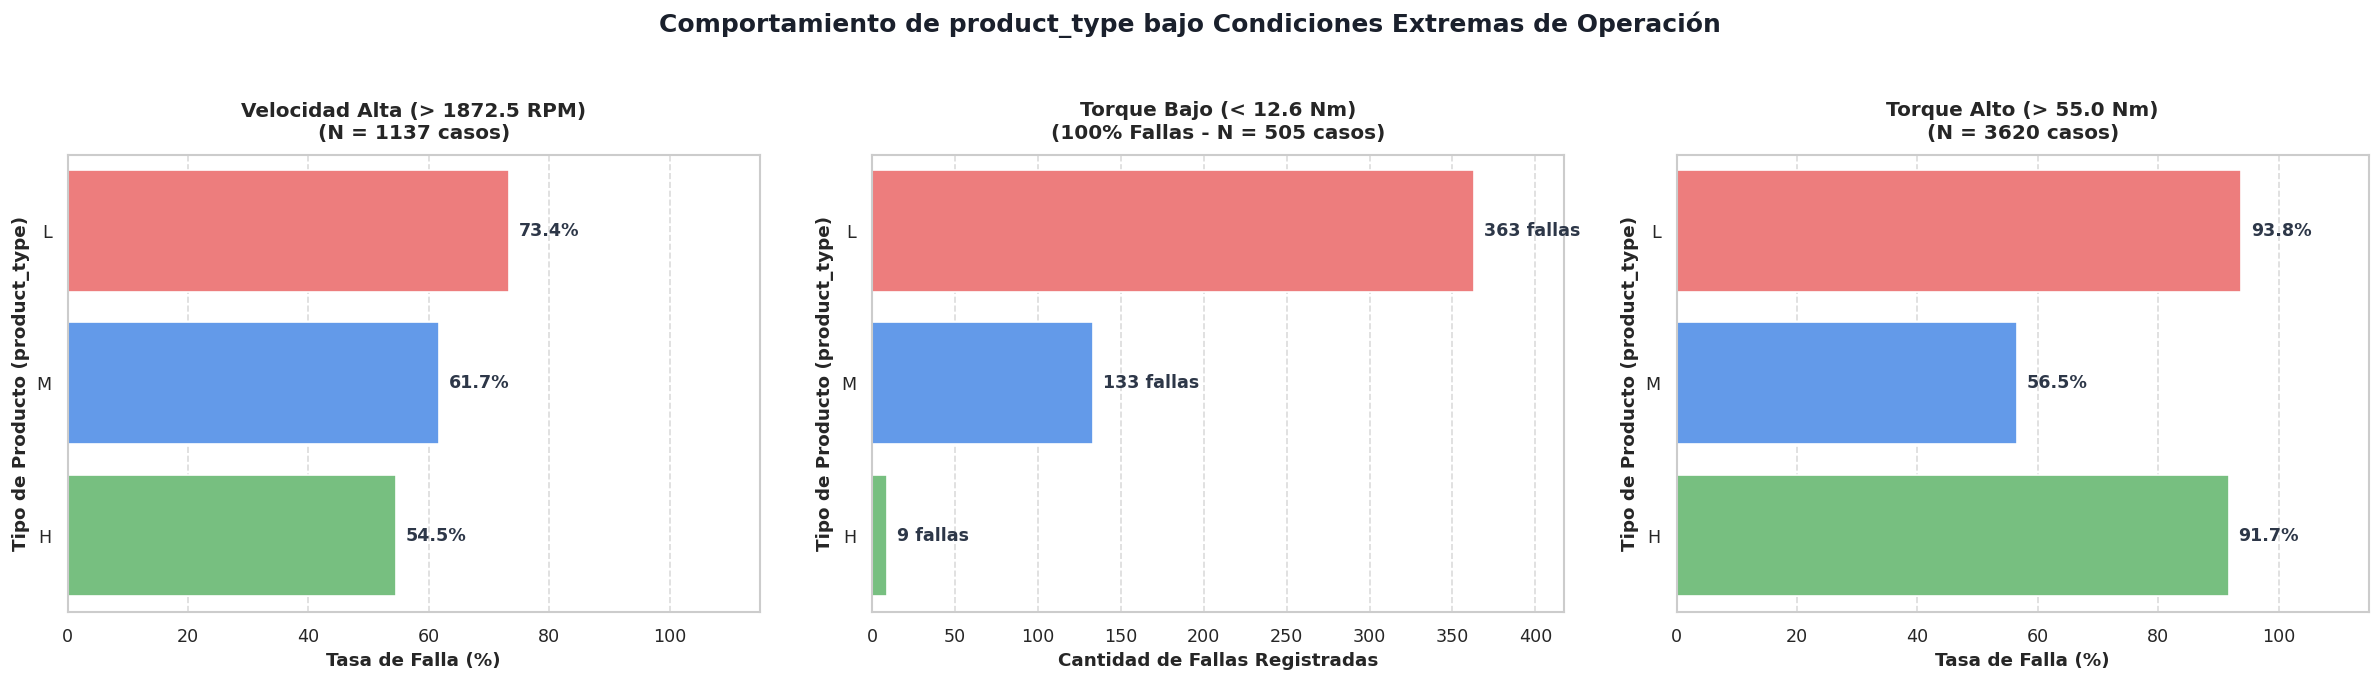

In [13]:
q1_speed = df[df['speed [RPM]'] >= 0]['speed [RPM]'].quantile(0.25)
q3_speed = df[df['speed [RPM]'] >= 0]['speed [RPM]'].quantile(0.75)
iqr_speed = q3_speed - q1_speed
limite_sup_speed = q3_speed + 1.5 * iqr_speed  # 1872.5 RPM

# Umbrales de Torque
umbral_torque_bajo = 12.6  # Predictor perfecto inferior
umbral_torque_alto = 55.0  # Tercer cuartil (Q3) de torque

df_temp = df.copy()
df_temp['target_bin'] = df_temp['target'].map({'normal': 0, 'failure': 1})

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5.5))

colores = {'L': '#FF6B6B', 'M': '#4D96FF', 'H': '#6BCB77'}

# GRÁFICO 1: Velocidad Alta
df_speed = df_temp[df_temp['speed [RPM]'] > limite_sup_speed]
tasas_speed = df_speed.groupby('product_type')['target_bin'].mean().reindex(['L', 'M', 'H']) * 100

sns.barplot(x=tasas_speed.values, y=tasas_speed.index, ax=axes[0], palette=colores, hue=tasas_speed.index, legend=False, orient='h')
axes[0].set_title(f'Velocidad Alta (> {limite_sup_speed:.1f} RPM)\n(N = {len(df_speed)} casos)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Tasa de Falla (%)', fontsize=11, fontweight='semibold')
axes[0].set_xlim(0, 115)

for bar in axes[0].patches:
    val = bar.get_width()
    if not pd.isna(val):
        axes[0].annotate(f'{val:.1f}%',
                         xy=(val, bar.get_y() + bar.get_height() / 2),
                         xytext=(6, 0), textcoords="offset points",
                         ha='left', va='center', fontsize=10.5, fontweight='bold', color='#2d3748')

# GRÁFICO 2: Torque Bajo (Cantidad de Fallas)
df_torque_low = df_temp[df_temp['torque [Nm]'] < umbral_torque_bajo]
cantidades_low = df_torque_low.groupby('product_type')['target_bin'].count().reindex(['L', 'M', 'H'])

sns.barplot(x=cantidades_low.values, y=cantidades_low.index, ax=axes[1], palette=colores, hue=cantidades_low.index, legend=False, orient='h')
axes[1].set_title(f'Torque Bajo (< {umbral_torque_bajo} Nm)\n(100% Fallas - N = {len(df_torque_low)} casos)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Cantidad de Fallas Registradas', fontsize=11, fontweight='semibold')
axes[1].set_xlim(0, cantidades_low.max() * 1.15)

for bar in axes[1].patches:
    val = bar.get_width()
    if not pd.isna(val):
        axes[1].annotate(f'{int(val)} fallas',
                         xy=(val, bar.get_y() + bar.get_height() / 2),
                         xytext=(6, 0), textcoords="offset points",
                         ha='left', va='center', fontsize=10.5, fontweight='bold', color='#2d3748')

# GRÁFICO 3: Torque Alto
df_torque_high = df_temp[df_temp['torque [Nm]'] > umbral_torque_alto]
tasas_high = df_torque_high.groupby('product_type')['target_bin'].mean().reindex(['L', 'M', 'H']) * 100

sns.barplot(x=tasas_high.values, y=tasas_high.index, ax=axes[2], palette=colores, hue=tasas_high.index, legend=False, orient='h')
axes[2].set_title(f'Torque Alto (> {umbral_torque_alto} Nm)\n(N = {len(df_torque_high)} casos)', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Tasa de Falla (%)', fontsize=11, fontweight='semibold')
axes[2].set_xlim(0, 115)

for bar in axes[2].patches:
    val = bar.get_width()
    if not pd.isna(val):
        axes[2].annotate(f'{val:.1f}%',
                         xy=(val, bar.get_y() + bar.get_height() / 2),
                         xytext=(6, 0), textcoords="offset points",
                         ha='left', va='center', fontsize=10.5, fontweight='bold', color='#2d3748')

for i, ax in enumerate(axes):
    ax.set_ylabel('Tipo de Producto (product_type)', fontsize=11, fontweight='semibold')
    ax.tick_params(labelsize=10.5)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
fig.suptitle('Comportamiento de product_type bajo Condiciones Extremas de Operación', 
             fontsize=15, fontweight='bold', y=1.03, color='#1a202c')

plt.tight_layout()
plt.show()

#### Conclusiones y Observaciones del Análisis de Condiciones Extremas

Para seguir con el estudio de la naturaleza ordinal de `product_type` (L < M < H), se revela el comportamiento físico real de cada calidad:

1. **Velocidad Alta (> 1872.5 RPM):**
   * Las tasas de falla siguen un orden decreciente según la calidad del material: L (73.4%) > M (61.7%) > H (54.5%). Bajo alto estrés térmico y fricción a altas revoluciones, la calidad premium (H) demuestra su superioridad presentando la menor propensión al fallo.

2. **Torque Bajo (< 12.6 Nm):**
   * En este rango la tasa de falla es del 100% para todas las calidades, pero el volumen de casos varía drásticamente: L (363 fallas) >> M (133 fallas) >> H (9 fallas). La mínima presencia de la calidad H en este régimen demuestra su gran robustez frente a fracturas de bajo torque (resistencia al colapso repentino) en comparación con la fragilidad de L.

3. **Torque Alto (> 55.0 Nm): Resiliencia del Tipo M ante Fatiga Torsional**
   * Ante esfuerzos torsionales elevados, las calidades L (93.8%) y H (91.7%) colapsan casi en su totalidad, mientras que el Tipo M demuestra una resiliencia ya que se observan 56.5% de fallas. 
      * Esto rompe con la intuición de ordinalidad, donde se esperaría un mejor desempeño para los productos de tipo H.

### Análisis de Correlación

#### Correlación de Pearson

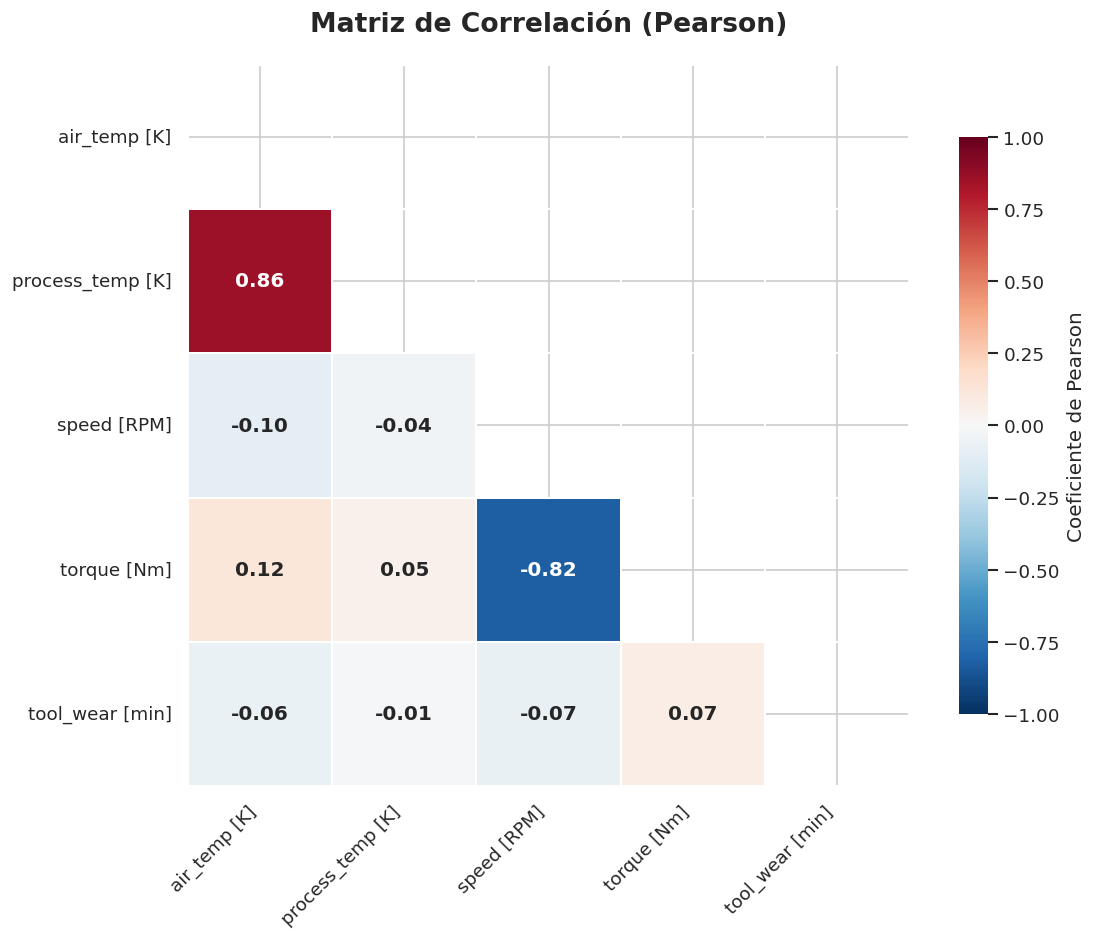

In [14]:
# --- Heatmap de la matriz de correlación (Pearson) ---

# Calcular la matriz de correlación solo para las columnas numéricas relevantes
corr_matrix = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Crear máscara para el triángulo superior (evitar redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Coeficiente de Pearson', 'shrink': 0.8})

ax.set_title('Matriz de Correlación (Pearson)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

#### Gráfico de Dispersión para Analizar Correlación entre Variables

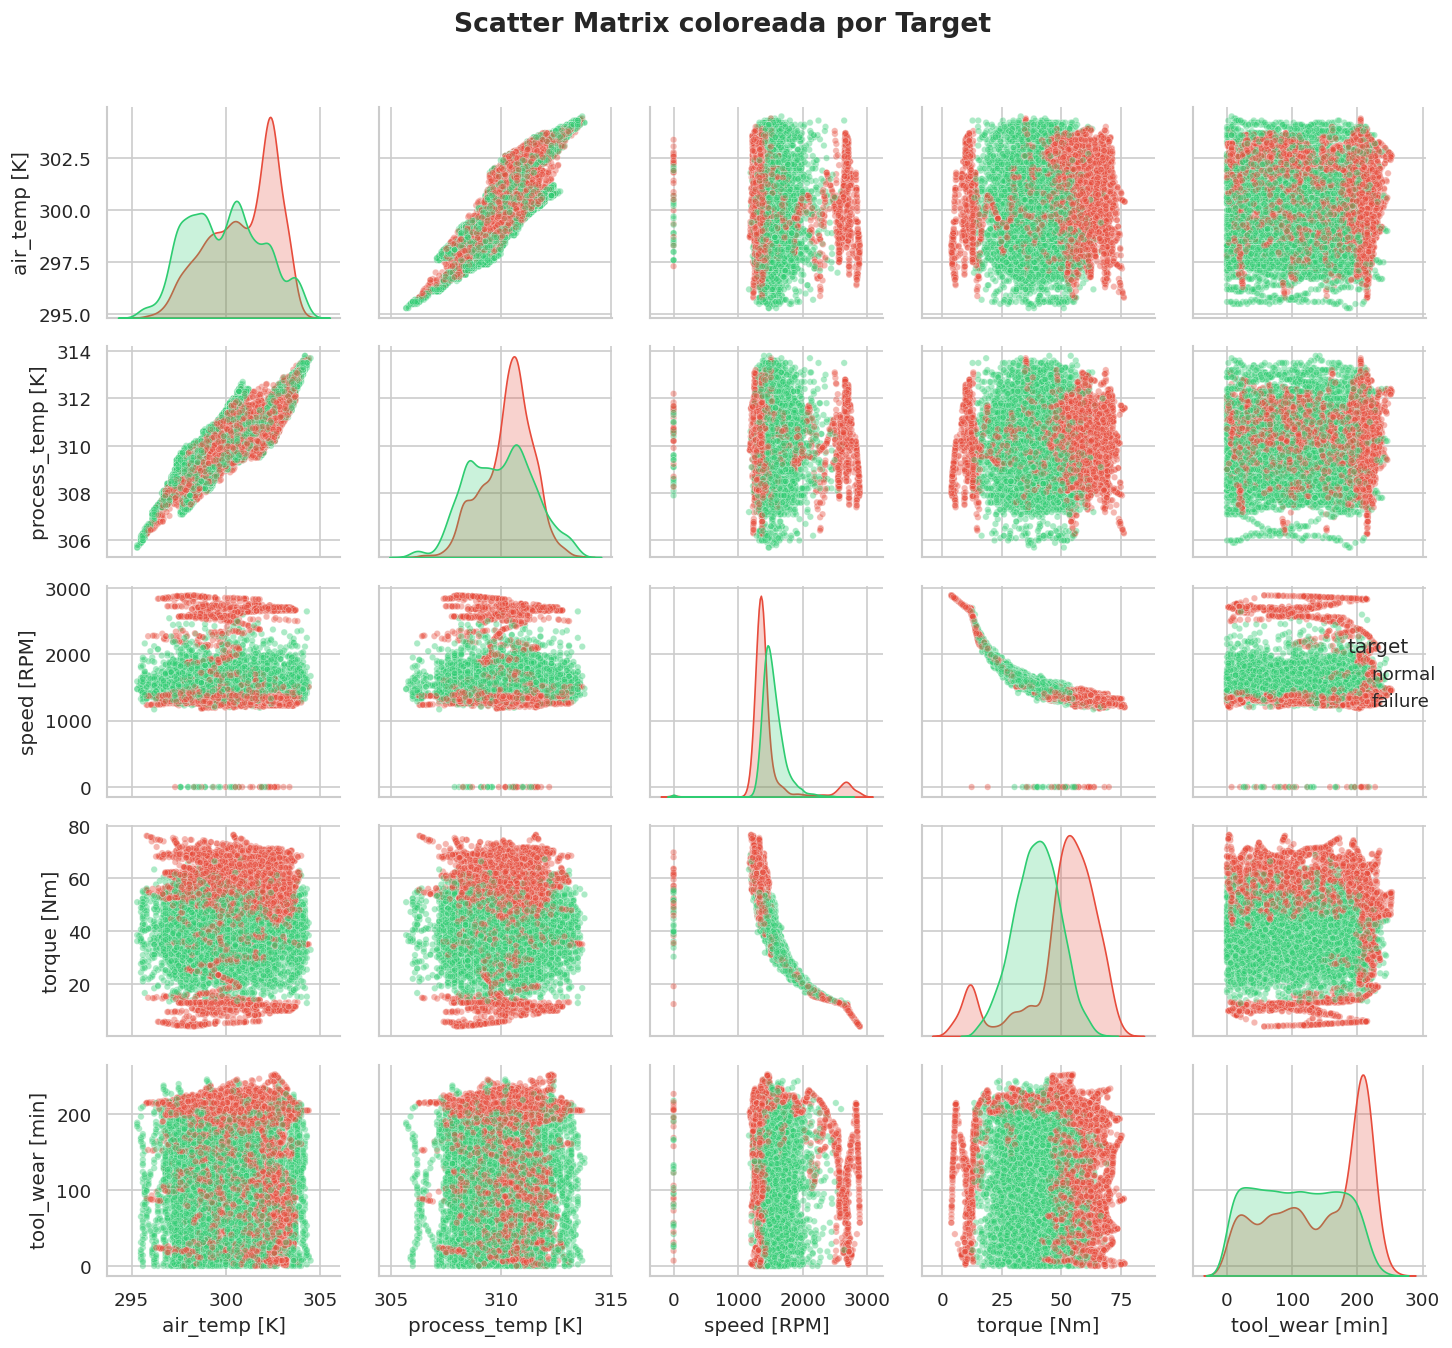

In [15]:
# --- Pairplot (scatter matrix) coloreado por la variable target ---

g = sns.pairplot(df[columnas_numericas + ['target']], hue='target',
                 palette={'failure': '#e74c3c', 'normal': '#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 height=2.2)

g.figure.suptitle('Scatter Matrix coloreada por Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- En este gráfico se puede observar que la relación entre speed [RPM] y torque [Nm] es bastante fuerte, lo que se refleja en el valor de la correlación de Pearson (-0.82) calculado anteriormente. Sin embargo, también se puede observar que dicha relación es no lineal, por lo que es importante también considerar la correlación de Spearman.
- Para el caso de air_temp [K] y process_temp [K], se puede observar que la relación entre ambas variables también es bastante fuerte, como sugiere el valor de la correlación de Pearson calculada anteriormente (0.86). En este caso, la relación sí pareciera ser lineal.

#### Correlación de Spearman

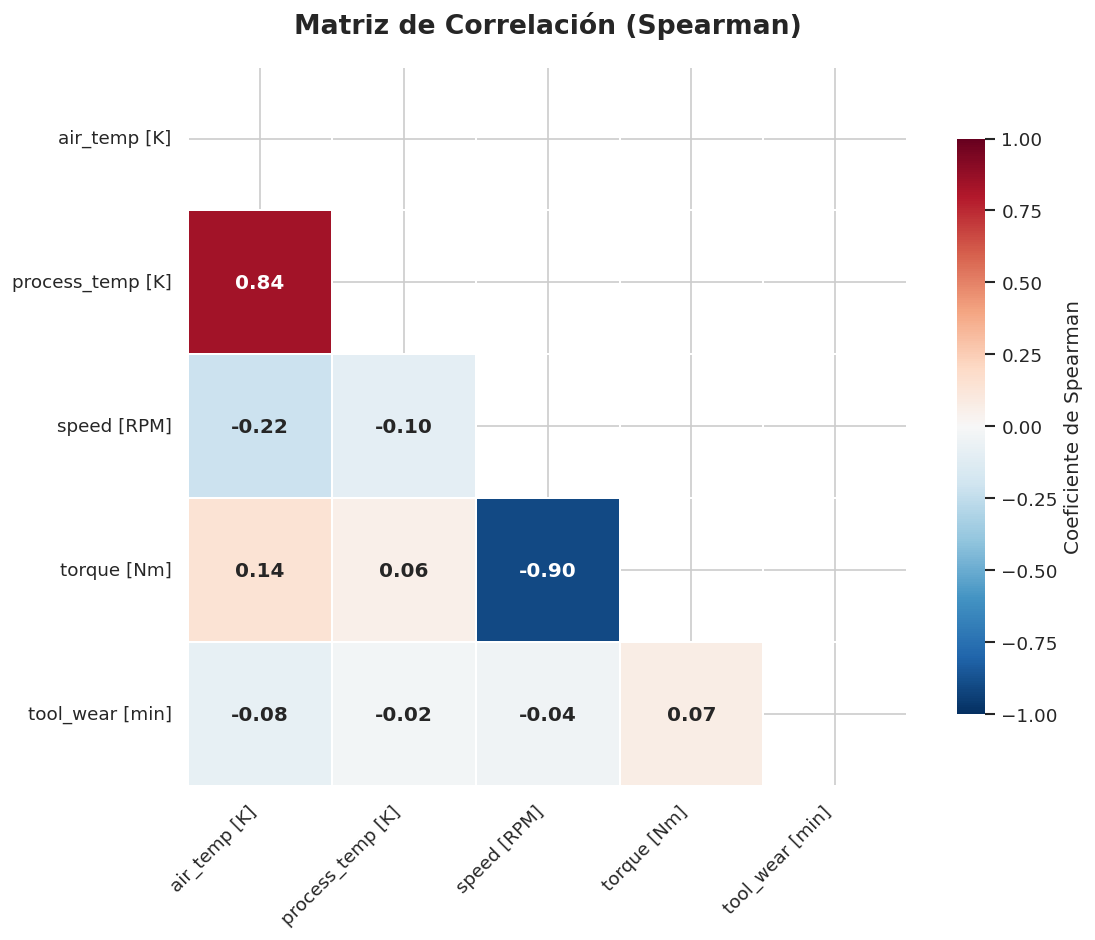

In [16]:
# --- Heatmap de la matriz de correlación (Spearman) ---
corr_spearman = df[columnas_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Coeficiente de Spearman', 'shrink': 0.8})

ax.set_title('Matriz de Correlación (Spearman)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

**Observaciones**:
- Con este resultado, podemos ver que la correlación de Spearman entre speed [RPM] y torque [Nm] es aún más fuerte que la correlación de Pearson, lo que sugiere que la relación entre estas dos variables es monotónica, aunque no necesariamente lineal. Esto refuerza la idea de que la relación entre speed y torque es fuerte, pero no lineal.

In [17]:
import scipy.stats as stats

mapping_ordinal = {'L': 1, 'M': 2, 'H': 3}

product_type_numeric = df['product_type'].map(mapping_ordinal)

coef_spearman, p_val_spearman = stats.spearmanr(product_type_numeric, df['target'])

print("=== PRUEBA 1: Correlación de Spearman ===")
print(f"Coeficiente de Spearman: {coef_spearman:.4f}")
print(f"P-valor (Spearman): {p_val_spearman:.4e}")
print("=" * 45)

tabla_contingencia = pd.crosstab(df['product_type'], df['target'])

chi2_stat, p_val_chi2, _, _ = stats.chi2_contingency(tabla_contingencia)

print("=== PRUEBA 2: Test Chi-Cuadrado de Independencia ===")
print(f"Estadístico Chi2: {chi2_stat:.2f}")
print(f"P-valor (Chi2): {p_val_chi2:.4e}")
print("=" * 45)

=== PRUEBA 1: Correlación de Spearman ===
Coeficiente de Spearman: 0.2349
P-valor (Spearman): 3.6072e-181
=== PRUEBA 2: Test Chi-Cuadrado de Independencia ===
Estadístico Chi2: 1331.57
P-valor (Chi2): 7.1156e-290


### Observaciones Finales: Validación de la Naturaleza de product_type

A partir de los resultados obtenidos en las pruebas estadísticas, se presentan las siguientes conclusiones clave respecto a la relación entre product_type (calidad L, M, H) y la variable objetivo target (0: normal, 1: failure):


#### 1. Resumen de Métricas Obtenidas
*   **Correlación de Spearman (Perspectiva Ordinal):** 
    *   **Coeficiente ($r_s$):** `0.2349`
    *   **$p$-valor:** `3.6072e-181` (Altamente significativo)
*   **Test Chi-Cuadrado $X^2$ (Perspectiva Nominal):** 
    *   **Estadístico ($X^2$):** `1331.57`
    *   **$p$-valor:** `7.1156e-290` (Extremadamente significativo)

#### 2. Interpretación Teórica de los Resultados

1.  **Significancia vs. Fuerza de Asociación (Spearman):**
    El test de Spearman arroja un $p$-valor virtualmente nulo ($3.6 \times 10^{-181}$), lo que estadísticamente descarta la hipótesis nula de no-monotonía. Sin embargo, el coeficiente de **$0.2349$** representa una **asociación monótona débil o moderada**. Esta debilidad en la correlación sugiere que la progresión jerárquica esperada (menor calidad $\to$ más fallas, o viceversa) no es uniforme. Esta distorsión suele ser evidencia de un desbalance o un *oversampling* focalizado (por ejemplo, una concentración desproporcionada de fallas en la clase 'H' o comportamientos no lineales entre 'L' y 'M'), lo que debilita el crecimiento monótono estricto a lo largo de la escala jerárquica.
    
2.  **Confirmación de Asociación Nominal (Chi-Cuadrado):**
    Por otro lado, el test de Chi-cuadrado presenta un estadístico sumamente elevado ($1331.57$) y un $p$-valor infinitamente más pequeño ($7.1 \times 10^{-290}$). Esto demuestra de manera contundente que **las tasas de fallo reales varían significativamente entre las categorías**, confirmando una **fuerte asociación de naturaleza principalmente nominal (o categórica pura)**. La categoría específica del producto aporta un gran poder discriminante sobre el target, independientemente de que se respete o no un orden lineal estricto.

#### 3. Implicancias para el Feature Engineering

*   **Evitar mapeos ordinales lineales simples (por ejemplo: L $\to$ 1, M $\to$ 2, H $\to$ 3):** Forzar una relación lineal con distancias equivalentes podría limitar la performance de modelos sensibles a la escala (como regresiones logísticas o redes neuronales), ya que la diferencia real en la tasa de fallas no se comporta de forma lineal.
*   **Tratamiento Categórico / Nominal:** Para optimizar el poder predictivo del modelo, se aconseja tratar la variable como nominal aplicando técnicas como **One-Hot Encoding** (o **Target Encoding** si se usan modelos basados en árboles que toleren alta cardinalidad). Esto permitirá al algoritmo estimar el impacto exacto y no lineal de cada tipo de producto de manera independiente.

## Parte 2.1: Preprocesamiento de los Datos

### Eliminar Columnas Irrelevantes

In [18]:
# Eliminamos las columnas idx y parent_device_id porque no brindan utilidad para el analisis
df = df.drop(columns=['idx', 'parent_device_id'])

### Análisis de la Variable product_type y Elección de Encoding
En esta sección se detalla el análisis realizado sobre la columna product_type para determinar su naturaleza (nominal u ordinal) y justificar la elección de su codificación para las etapas de modelado predictivo.

#### 1. Hipótesis Inicial
La documentación del dataset no especifica el significado de las etiquetas L, M y H. Nuestra hipótesis de partida fue que representan la calidad o robustez del tipo de producto fabricado (L = Low, M = Medium, H = High).

De ser correcta, la variable tendría naturaleza **ordinal** (L < M < H), lo que permitiría aplicar **Ordinal Encoding** (L=1, M=2, H=3) preservando la jerarquía y reduciendo dimensionalidad.

#### 2. Hallazgos en el EDA

**2.1 Distorsión por sobremuestreo**: Al analizar las tasas de falla globales por grupo, el patrón observado es **no monótono**:

| Tipo | Instancias | Fallas | Tasa de falla |
|------|-----------|--------|---------------|
| L    | 10,362    | 6,200  | 59.83%        |
| M    | 2,691     |   549  | 20.40%        |
| H    | 1,468     |   733  | 49.93%        |

El grupo H presenta más del doble de tasa de falla que M, lo cual contradice la hipótesis de robustez creciente. Atribuimos esta anomalía a un **artefacto del proceso de sobremuestreo**: al balancear las clases globalmente, el algoritmo infló de forma desproporcionada las observaciones de falla en H (la categoría minoritaria original), distorsionando las proporciones reales.

Esta hipótesis se ve respaldada por el análisis de torque bajo (< 12.6 Nm), donde las fallas reales se distribuyen de forma consistente con la hipótesis ordinal: L: 363 fallas, M: 133, H: 9.

**2.2 El patrón ordinal sí aparece en condiciones extremas**: Segmentando por velocidad alta (> 1872 RPM), las tasas de falla recuperan la monotonía esperada:

- **L:** 73.3% · **M:** 61.7% · **H:** 53.7%
Esto sugiere que la relación de robustez físicamente existe, pero el sobremuestreo la enmascara en el dataset completo.

**2.3 Perfil de falla cualitativamente distinto en M**: El análisis de distribuciones por variable numérica (boxplots por tipo y target) revela una diferencia estructural entre M y los demas grupos:
- En **L** y **H**, las fallas se asocian con **torque alto** (mediana ~55 Nm vs. ~40 Nm en operación normal).
- En **M**, el patrón es **inverso**: las fallas se asocian con **torque bajo** (~40 Nm vs. ~50 Nm en operación normal).
Esto indica que M no solo falla menos, sino que falla bajo condiciones mecánicas opuestas a L y H. Esto descarta que M sea un punto intermedio ya que su comportamiento es cualitativamente distinto.


#### 3. Pruebas Estadísticas

**Prueba 1: Correlación de Spearman (monotonía global)**
Si existiera una relación ordinal monótona L --> M  --> H, deberíamos observar una correlación de Spearman alta y negativa entre el encoding ordinal y el target.

$$\rho = -0.2349 \qquad p = 3.6 \times 10^{-181}$$

Aunque estadísticamente significativa por el volumen de datos, la correlación es débil y no monótona: la tasa de falla decrece de $L$ a $M$ pero repunta marcadamente en $H$. El encoding ordinal no captura la relación real.

**Prueba 2: Test $\chi^2$ de independencia (asociación nominal)**
Evaluando la relación sin asumir orden:

$$\chi^2 = 1331.57 \qquad p = 7.12 \times 10^{-290}$$

La asociación entre product_type y el target es extremadamente fuerte. Sin embargo, al no asumir orden, el test confirma que el grupo  influye en la falla de forma **nominal**, no ordinal. Combinado con la Prueba 1, esto indica que product_type ayuda a distinguir casos de falla y no falla, pero no puede interpretarse correctamente usando un encoding ordinal lineal (L=1, M=2, H=3), porque las categorías no siguen una progresión ordenada consistente.


#### 4. Conclusión y Elección del Encoding
Las pruebas estadísticas y el análisis exploratorio convergen en la misma dirección: **no es metodológicamente correcto forzar un Ordinal Encoding en este dataset**.

Aplicar L=1, M=2, H=3 introduciría el supuesto de que M se encuentra en un punto intermedio de riesgo entre L y H. Los datos muestran lo contrario: 
- M es el grupo más seguro (20% de falla) y falla bajo condiciones mecánicas opuestas a los otros grupos. 
Forzar esa linealidad sesgaría los modelos basados en distancia, que interpretarían incorrectamente las magnitudes relativas.

Finalmente, **se opta por One-Hot Encoding**, que:
1. Captura de forma independiente el comportamiento real de cada grupo, respetando la fuerte asociación nominal revelada por el $\chi^2$.
2. No impone ninguna relación de orden o distancia entre los grupos.
3. Permite al modelo aprender libremente el peso predictivo de cada categoría sin restricciones artificiales.

### Codificación de Columnas Categóricas

In [19]:
# Se aplica One-Hot Encoding a la columna product_type
df = pd.get_dummies(df, columns=['product_type'], prefix='product_type', drop_first=False, dtype=int)

# Codificación de la variable objetivo (Target)
# Convertimos los valores string a numéricos (0 y 1) para que los modelos puedan procesarlos
df['target'] = df['target'].map({'normal': 0, 'failure': 1})

print("\nPrimeras filas del DataFrame con product_type codificado (One-Hot Encoding) y target codificado:")
df.head()


Primeras filas del DataFrame con product_type codificado (One-Hot Encoding) y target codificado:


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target,product_type_H,product_type_L,product_type_M
0,303.80,313.30,1406,52.10,166,0,0,1,0
1,302.30,311.20,1633,36.40,114,0,0,1,0
2,302.27,311.47,1228,68.75,187,1,0,0,1
3,302.35,311.93,1522,36.99,214,1,0,1,0
4,296.70,307.90,1743,27.90,55,0,0,1,0


**Observación:** Si bien inicialmente interpretamos que la columna product_type era categórica ordinal (siendo L=Low, M=Medium y H=High), como el trabajo no provee información explícita decidimos no arriesgarnos a una interpretación errónea y optamos por aplicar One-Hot Encoding a esta columna, lo que nos permite preservar toda la información sin asumir un orden específico entre las categorías. De esta manera, cada categoría de product_type se representa como una columna binaria independiente, lo que facilita el análisis y modelado posterior sin introducir suposiciones sobre la relación entre las categorías.

### Verificación de Valores Faltantes

In [20]:
# Verificar si existen valores faltantes
df.isnull().sum()

air_temp [K]        40
process_temp [K]     0
speed [RPM]          0
torque [Nm]          0
tool_wear [min]      0
target               0
product_type_H       0
product_type_L       0
product_type_M       0
dtype: int64

**Observación**: Hay 40 filas con valores faltantes en la columna air_temp [K].

In [21]:
# Observamos las filas con la columna air_temp [K] faltante
df[pd.isnull(df['air_temp [K]'])]

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target,product_type_H,product_type_L,product_type_M
1448,NaN,312.40,1404,61.50,127,1,0,1,0
1449,NaN,311.51,1371,47.22,60,1,0,1,0
1450,NaN,309.51,1337,63.61,206,1,0,1,0
3901,NaN,309.82,1981,20.50,203,1,0,1,0
3902,NaN,311.00,1428,47.90,174,0,0,1,0
3903,NaN,312.34,2687,10.48,67,1,0,0,1
3904,NaN,311.50,1663,33.60,38,0,0,1,0
3905,NaN,308.00,1423,38.00,154,0,0,1,0
3906,NaN,311.10,1647,31.60,6,0,0,0,1
3907,NaN,308.80,1683,31.60,79,0,0,0,1


## División del dataset (80/20)

In [22]:
from sklearn.model_selection import train_test_split

# Se separa features (X) y target (y)
X = df.drop(columns=['target'])
y = df['target']

# División 80% train / 20% test, con estratificación para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nDistribución de clases en train:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribución de clases en test:\n{y_test.value_counts(normalize=True)}")

Train: 11616 muestras (80.0%)
Test:  2905 muestras (20.0%)

Distribución de clases en train:
target
1    0.515238
0    0.484762
Name: proportion, dtype: float64

Distribución de clases en test:
target
1    0.515318
0    0.484682
Name: proportion, dtype: float64


## Imputación de Valores Inválidos
Para la imputación de valores inválidos (como los -1 de la columna speed), decidimos hacer lo siguiente:
Para cada fila con speed == -1:
- Buscar filas con torque parecido que tengan speed != -1
- Usar sus valores de speed para imputar el valor faltante.

In [23]:
# Unimos Train y Test para buscar en todo el dataset
concatenado = pd.concat([X_train, X_test], axis=0)
filas_speed_negativo = concatenado[concatenado['speed [RPM]'] == -1]
display(filas_speed_negativo)

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M
8668,298.90,309.60,-1,33.70,195,0,1,0
8677,303.06,311.50,-1,49.02,88,0,1,0
8687,300.30,310.40,-1,54.40,52,0,1,0
58,300.70,311.35,-1,19.05,227,0,0,1
51,300.70,310.60,-1,30.30,96,0,1,0
8680,298.72,309.23,-1,61.47,216,0,1,0
56,301.42,309.91,-1,63.77,20,1,0,0
1786,301.83,311.83,-1,57.29,209,0,1,0
55,300.87,310.56,-1,38.26,206,0,1,0
53,302.70,312.20,-1,52.10,213,0,1,0


In [24]:
from sklearn.neighbors import KNeighborsRegressor

# Entrenar el imputador usando sólo los registros válidos de Train
train_validos = X_train[X_train['speed [RPM]'] != -1]

# Ajustamos un regresor de KNN donde la entrada es el torque y la salida es la velocidad
imputador_speed = KNeighborsRegressor(n_neighbors=5)
imputador_speed.fit(train_validos[['torque [Nm]']], train_validos['speed [RPM]'])

# Imputar en X_train (usando el modelo entrenado)
mask_invalidos_train = X_train['speed [RPM]'] == -1
if mask_invalidos_train.any():
    valores_imputados_train = imputador_speed.predict(X_train.loc[mask_invalidos_train, ['torque [Nm]']])
    X_train.loc[mask_invalidos_train, 'speed [RPM]'] = np.round(valores_imputados_train)
    print(f"Imputados {mask_invalidos_train.sum()} valores -1 en speed [train]")

# Imputar en X_test (usando el modelo entrenado en Train, evitando data leakage)
mask_invalidos_test = X_test['speed [RPM]'] == -1
if mask_invalidos_test.any():
    valores_imputados_test = imputador_speed.predict(X_test.loc[mask_invalidos_test, ['torque [Nm]']])
    X_test.loc[mask_invalidos_test, 'speed [RPM]'] = np.round(valores_imputados_test)
    print(f"Imputados {mask_invalidos_test.sum()} valores -1 en speed [test]")


Imputados 40 valores -1 en speed [train]
Imputados 7 valores -1 en speed [test]


Chequeo de que la imputación fue satisfactoria:

In [25]:
# Verificar que no queden filas con speed == -1 en X_train
print("Valores -1 en X_train['speed [RPM]']:", (X_train['speed [RPM]'] == -1).sum())
print("Valores -1 en X_test['speed [RPM]']:", (X_test['speed [RPM]'] == -1).sum())

# Verificar los valores imputados en las filas que antes tenían air_temp [K] faltante
concatenado = pd.concat([X_train, X_test], axis=0)
indices_air_temp_nulo = df[df['air_temp [K]'].isnull()].index
concatenado.loc[indices_air_temp_nulo, 'air_temp [K]']

Valores -1 en X_train['speed [RPM]']: 0
Valores -1 en X_test['speed [RPM]']: 0


1448    NaN
1449    NaN
1450    NaN
3901    NaN
3902    NaN
3903    NaN
3904    NaN
3905    NaN
3906    NaN
3907    NaN
6682    NaN
6683    NaN
6713    NaN
12100   NaN
12101   NaN
12102   NaN
12103   NaN
12104   NaN
12105   NaN
12106   NaN
12107   NaN
12108   NaN
12109   NaN
12110   NaN
12111   NaN
12112   NaN
12113   NaN
12114   NaN
12115   NaN
12116   NaN
12117   NaN
12118   NaN
12119   NaN
12120   NaN
12121   NaN
12122   NaN
14328   NaN
14329   NaN
14330   NaN
14331   NaN
Name: air_temp [K], dtype: float64

## Normalización / Estandarización

Mirando las columnas:
- air_temp [K] → ~296-303 (rango pequeño)
- process_temp [K] → ~307-313 (rango pequeño)
- speed [RPM] → ~1200-1700 (rango grande)
- torque [Nm] → ~27-68 (rango medio)
- tool_wear [min] → ~0-250 (rango grande)

Las escalas son muy diferentes entre sí, entonces, para evitar que las variables con magnitudes altas (como las RPM) dominen sobre las de magnitudes bajas (como las temperaturas), aplicamos estandarización (StandardScaler). Este proceso transforma las variables numéricas calculando su Z-score ($z = \frac{x - \mu}{\sigma}$), logrando que todas tengan una media de 0 y una desviación estándar de 1.

In [26]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
scaler = StandardScaler()

# fit_transform SOLO en train (para evitar data leakage)
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# transform en test (usando los parámetros aprendidos del train)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print("Estadísticas del train después del escalado:")
print(X_train[cols_to_scale].describe().round(2))

Estadísticas del train después del escalado:
       air_temp [K]  process_temp [K]  speed [RPM]  torque [Nm]  \
count      11581.00          11616.00     11616.00     11616.00   
mean          -0.00             -0.00         0.00        -0.00   
std            1.00              1.00         1.00         1.00   
min           -2.67             -3.38        -1.16        -2.90   
25%           -0.81             -0.73        -0.54        -0.63   
50%            0.06              0.14        -0.31         0.13   
75%            0.89              0.69         0.14         0.70   
max            2.07              2.75         4.56         2.22   

       tool_wear [min]  
count         11616.00  
mean             -0.00  
std               1.00  
min              -1.79  
25%              -0.86  
50%               0.05  
75%               0.96  
max               1.82  


## Imputación de NaNs en air_temp

In [27]:
# Cantidad de valores nules en el conjunto de entrenamiento y de pruebo
nulos_df = pd.DataFrame({'Train (Cantidad Nulos)': X_train.isnull().sum(), 'Test (Cantidad Nulos)': X_test.isnull().sum()})
display(nulos_df)

todos_los_indices_nulos = df[df['air_temp [K]'].isnull()].index

,Train (Cantidad Nulos),Test (Cantidad Nulos)
air_temp [K],35,5
process_temp [K],0,0
speed [RPM],0,0
torque [Nm],0,0
tool_wear [min],0,0
product_type_H,0,0
product_type_L,0,0
product_type_M,0,0


In [28]:
from sklearn.impute import KNNImputer

# Variables numéricas para imputar razonablemente
columnas_imputacion = ['product_type_L', 'product_type_M', 'product_type_H', 'air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

# Imputador KNN con 5 vecinos 
imputer = KNNImputer(n_neighbors=5)

X_train[columnas_imputacion] = imputer.fit_transform(X_train[columnas_imputacion])
X_test[columnas_imputacion] = imputer.transform(X_test[columnas_imputacion])

**Observación**: Se imputa luego de haber normalizado/estandarizado ya que se utiliza un imputador basado en KNN. Como este es un modelo basado en distancias la escala importa, por lo que se debía realizar este tratamiento previo. No fue así para la imputación de Speed ya que se utilizó unicamente el Torque para realizar esta imputación, manteniendo los problemas de escalas distintas alejados. 

In [29]:
# Verificar que no queden valores faltantes
no_nulos_df = pd.DataFrame({'Train (Cantidad Nulos)': X_train.isnull().sum(), 'Test (Cantidad Nulos)': X_test.isnull().sum()})
display(no_nulos_df)

,Train (Cantidad Nulos),Test (Cantidad Nulos)
air_temp [K],0,0
process_temp [K],0,0
speed [RPM],0,0
torque [Nm],0,0
tool_wear [min],0,0
product_type_H,0,0
product_type_L,0,0
product_type_M,0,0


In [30]:
# Verificar los valores imputados en las filas que antes tenían air_temp [K] faltante
concatenado = pd.concat([X_train, X_test], axis=0)
resultado = concatenado.loc[todos_los_indices_nulos, ['air_temp [K]']]
display(resultado)

,air_temp [K]
1448,1.304832
1449,1.486144
1450,-0.497989
3901,-0.011743
3902,0.391059
3903,1.555167
3904,0.185023
3905,-1.597195
3906,0.638303
3907,-1.051198


## Guardar dataset preprosesado

In [31]:
import os

os.makedirs('data/processed', exist_ok=True)

train_df = X_train.copy()
train_df['target'] = y_train.values

test_df = X_test.copy()
test_df['target'] = y_test.values

train_df.to_csv('data/processed/train.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

print(f"Train exportado: {train_df.shape[0]} filas, {train_df.shape[1]} columnas")
print(f"Test exportado: {test_df.shape[0]} filas, {test_df.shape[1]} columnas")

Train exportado: 11616 filas, 9 columnas
Test exportado: 2905 filas, 9 columnas


## Parte 2.2: Entrenamiento de Modelos

- Entrenar y mostrar los resultados obtenidos con los modelos KNN, Naive Bayes y Decision Trees
- Realizar búsqueda de hiperparámetros con RandomSearch
- Evaluar los modelos con las métricas convenientes.

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Función reutilizable para evaluar modelos
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"--- Resultados para {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal (0)', 'Falla (1)'], 
                yticklabels=['Normal (0)', 'Falla (1)'])
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

### KNN

Mejores hiperparámetros KNN: {'weights': 'uniform', 'n_neighbors': 1, 'metric': 'minkowski'}

--- Resultados para KNN ---
Accuracy:  0.9594
Precision: 0.9389
Recall:    0.9853
F1-Score:  0.9615

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      1408
           1       0.94      0.99      0.96      1497

    accuracy                           0.96      2905
   macro avg       0.96      0.96      0.96      2905
weighted avg       0.96      0.96      0.96      2905



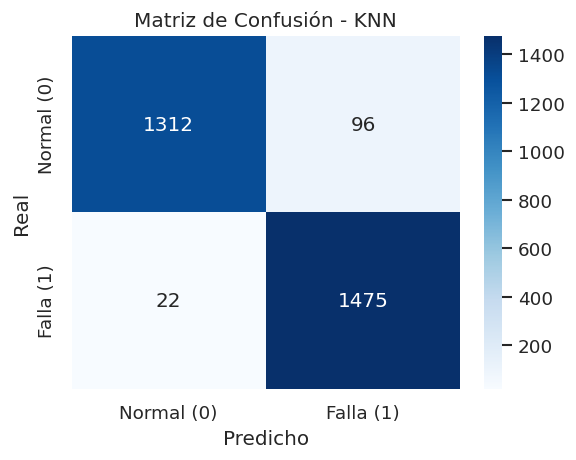

In [33]:
from sklearn.neighbors import KNeighborsClassifier

param_dist_knn = {
    'n_neighbors': range(1, 40),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()

# Búsqueda de hiperparámetros con Random Search 
# (Optimizamos para f1 debido a la importancia de detectar fallas)
rs_knn = RandomizedSearchCV(knn, param_distributions=param_dist_knn, 
                            n_iter=50, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_knn.fit(X_train, y_train)

print(f"Mejores hiperparámetros KNN: {rs_knn.best_params_}\n")

best_knn = rs_knn.best_estimator_
evaluate_model(best_knn, X_test, y_test, "KNN")

### Naive Bayes

Mejores hiperparámetros Naive Bayes: {'var_smoothing': np.float64(0.3511191734215131)}

--- Resultados para Naive Bayes ---
Accuracy:  0.8437
Precision: 0.8337
Recall:    0.8704
F1-Score:  0.8516

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.82      0.83      1408
           1       0.83      0.87      0.85      1497

    accuracy                           0.84      2905
   macro avg       0.84      0.84      0.84      2905
weighted avg       0.84      0.84      0.84      2905



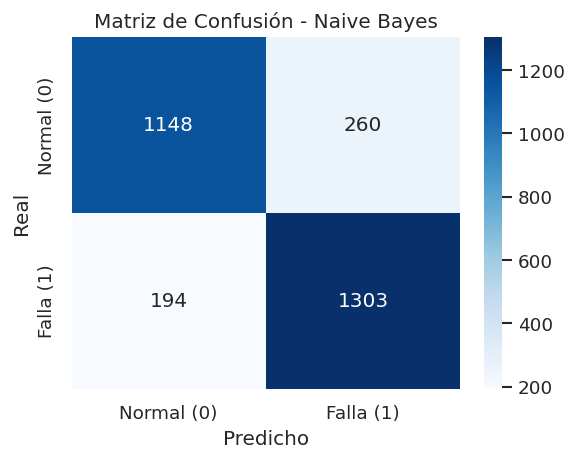

In [34]:
from sklearn.naive_bayes import GaussianNB

# var_smoothing ayuda a la estabilidad del cálculo al agregar una porción de la mayor varianza a todas las características
param_dist_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb = GaussianNB()

# Búsqueda de hiperparámetros con Random Search
rs_nb = RandomizedSearchCV(nb, param_distributions=param_dist_nb, 
                           n_iter=50, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_nb.fit(X_train, y_train)

print(f"Mejores hiperparámetros Naive Bayes: {rs_nb.best_params_}\n")

best_nb = rs_nb.best_estimator_
evaluate_model(best_nb, X_test, y_test, "Naive Bayes")

### Decision Trees

Total de combinaciones posibles: 8208
Mejores hiperparámetros Decision Tree: {'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'entropy', 'class_weight': None}

--- Resultados para Decision Trees ---
Accuracy:  0.9525
Precision: 0.9462
Recall:    0.9626
F1-Score:  0.9543

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1408
           1       0.95      0.96      0.95      1497

    accuracy                           0.95      2905
   macro avg       0.95      0.95      0.95      2905
weighted avg       0.95      0.95      0.95      2905



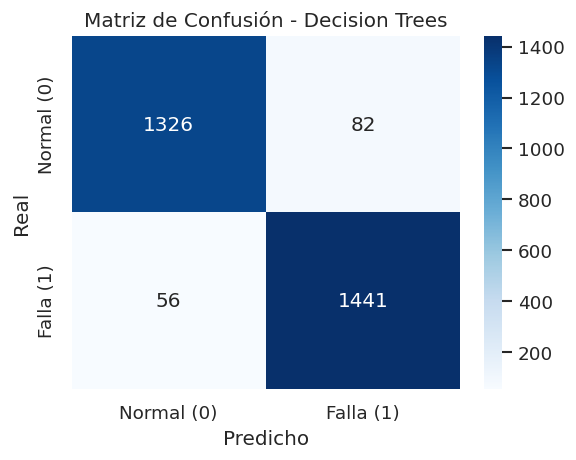

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid

param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 20),
    'class_weight': [None, 'balanced']  # ya que tenemos un ligero desbalanceo de clases
}
total_combinaciones = len(ParameterGrid(param_dist_dt))
print(f"Total de combinaciones posibles: {total_combinaciones}")

dt = DecisionTreeClassifier(random_state=42)

# Búsqueda de hiperparámetros con Random Search
rs_dt = RandomizedSearchCV(dt, param_distributions=param_dist_dt, 
                           n_iter=100, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_dt.fit(X_train, y_train)

print(f"Mejores hiperparámetros Decision Tree: {rs_dt.best_params_}\n")

best_dt = rs_dt.best_estimator_
evaluate_model(best_dt, X_test, y_test, "Decision Trees")

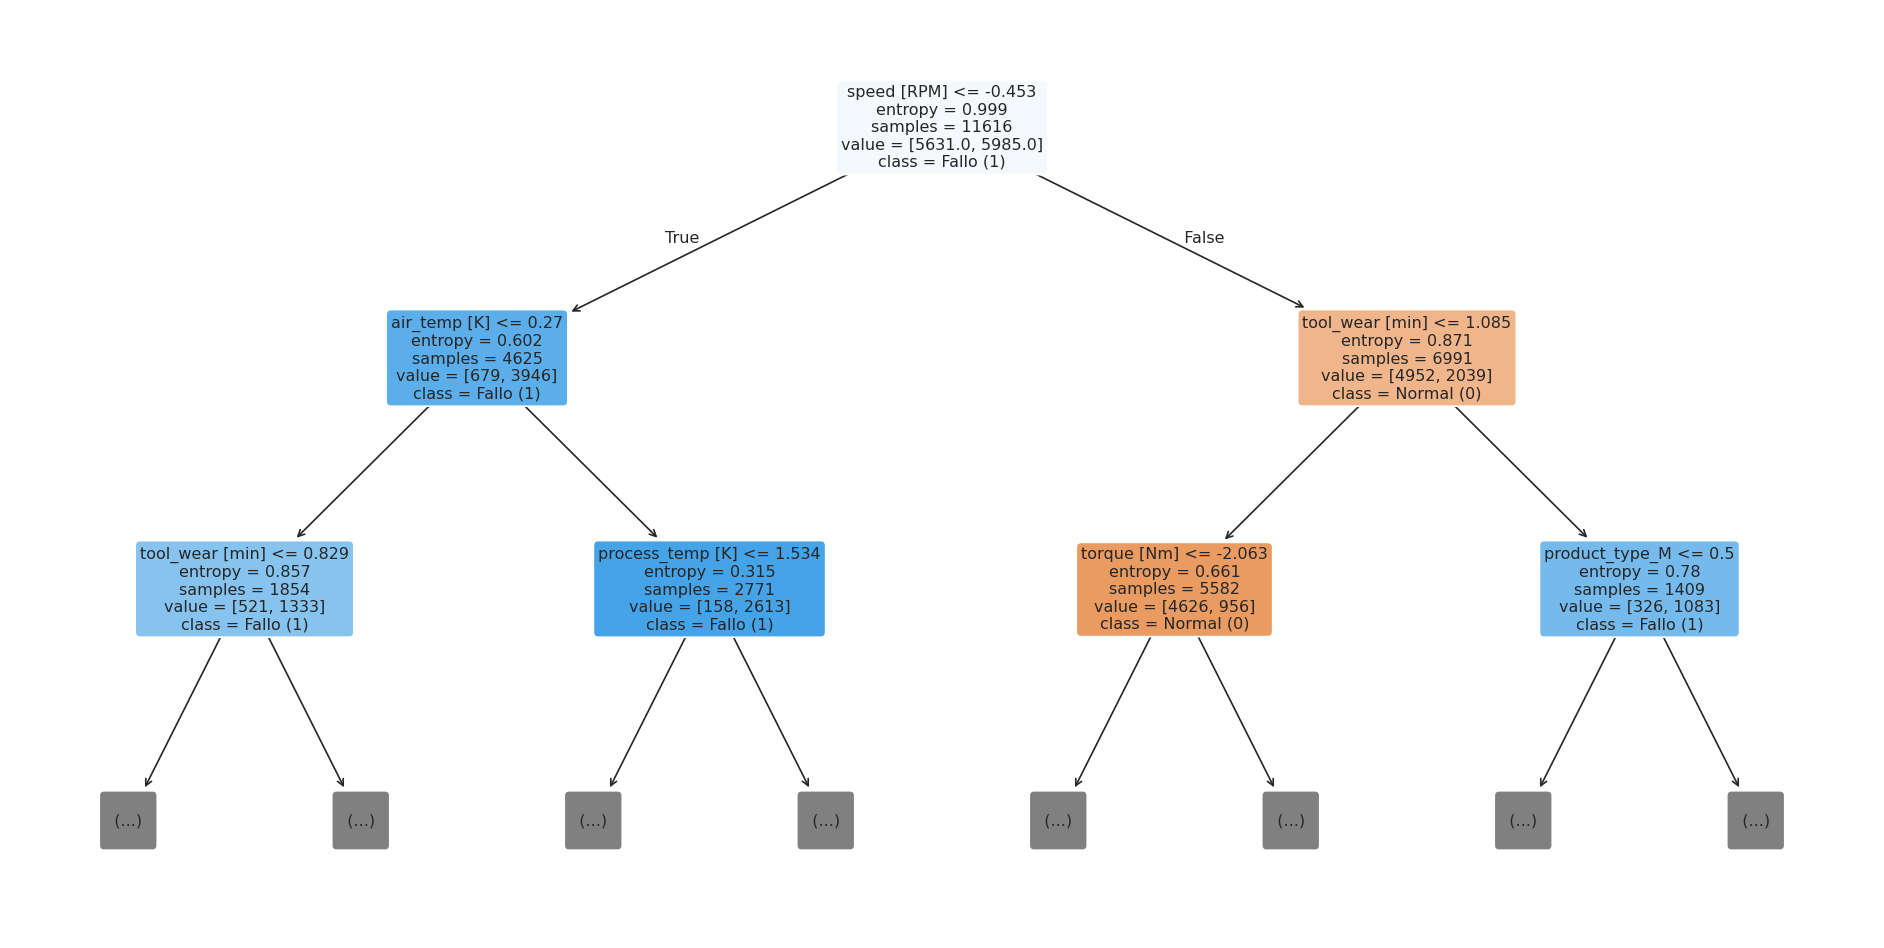

In [36]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

nombres_clases = [str(c) for c in best_dt.classes_]

plot_tree(best_dt, 
          filled=True,                     
          feature_names=X_train.columns,   
          class_names=['Normal (0)', 'Fallo (1)'],
          rounded=True,                    
          max_depth=2)                     

plt.show()

## Parte 2.3: Entrenamiento de Modelos Ensamblados

Mejores hiperparámetros Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 30, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': False}

--- Resultados para Random Forest ---
Accuracy:  0.9721
Precision: 0.9658
Recall:    0.9806
F1-Score:  0.9732

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1408
           1       0.97      0.98      0.97      1497

    accuracy                           0.97      2905
   macro avg       0.97      0.97      0.97      2905
weighted avg       0.97      0.97      0.97      2905



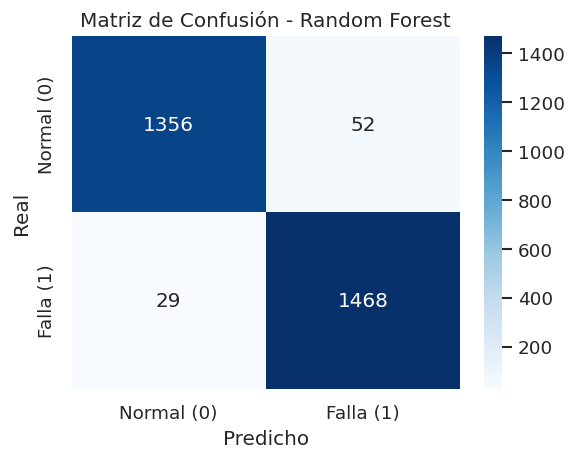

In [37]:
from sklearn.ensemble import RandomForestClassifier

param_dist_rf = {
    'n_estimators': [25, 50, 100, 200, 300, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 20),
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']  # ya que tenemos un ligero desbalanceo de clases
}
    
rf = RandomForestClassifier(random_state=42)

rs_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf, 
                           n_iter=100, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_rf.fit(X_train, y_train)

print(f"Mejores hiperparámetros Random Forest: {rs_rf.best_params_}\n")

# Evaluar el mejor modelo encontrado
best_rf = rs_rf.best_estimator_
evaluate_model(best_rf, X_test, y_test, "Random Forest")

## Parte 2.4: Comparación de Modelos

,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Random Forest,0.9721,0.9658,0.9806,0.9732
KNN,0.9594,0.9389,0.9853,0.9615
Decision Tree,0.9525,0.9462,0.9626,0.9543
Naive Bayes,0.8437,0.8337,0.8704,0.8516


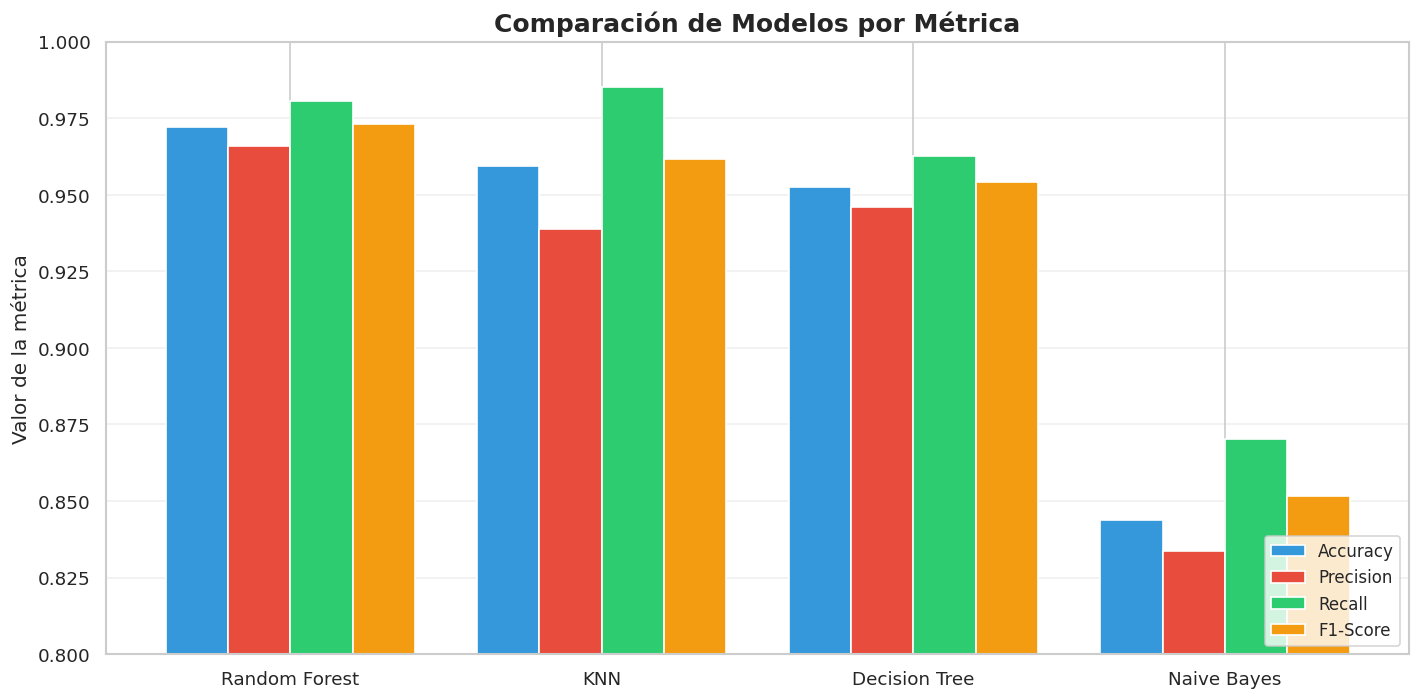

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Diccionario de modelos ya entrenados (mejores estimadores de cada RandomizedSearch)
modelos = {
    'KNN': best_knn,
    'Naive Bayes': best_nb,
    'Decision Tree': best_dt,
    'Random Forest': best_rf
}

# Calcular métricas sobre el conjunto de prueba
filas = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

comparacion = pd.DataFrame(filas).set_index('Modelo').sort_values('F1-Score', ascending=False)
display(comparacion.round(4))

# Gráfico de barras comparativo ---
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparacion.index))
ancho = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, met in enumerate(metricas):
    ax.bar(x + i * ancho, comparacion[met], ancho, label=met, color=colores[i], edgecolor='white')

ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(comparacion.index, fontsize=11)
ax.set_ylabel('Valor de la métrica', fontsize=12)
ax.set_ylim(0.80, 1.0)  # zoom para apreciar las diferencias
ax.set_title('Comparación de Modelos por Métrica', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

,AUC
Modelo,
Random Forest,0.9970
Decision Tree,0.9587
KNN,0.9586
Naive Bayes,0.9155


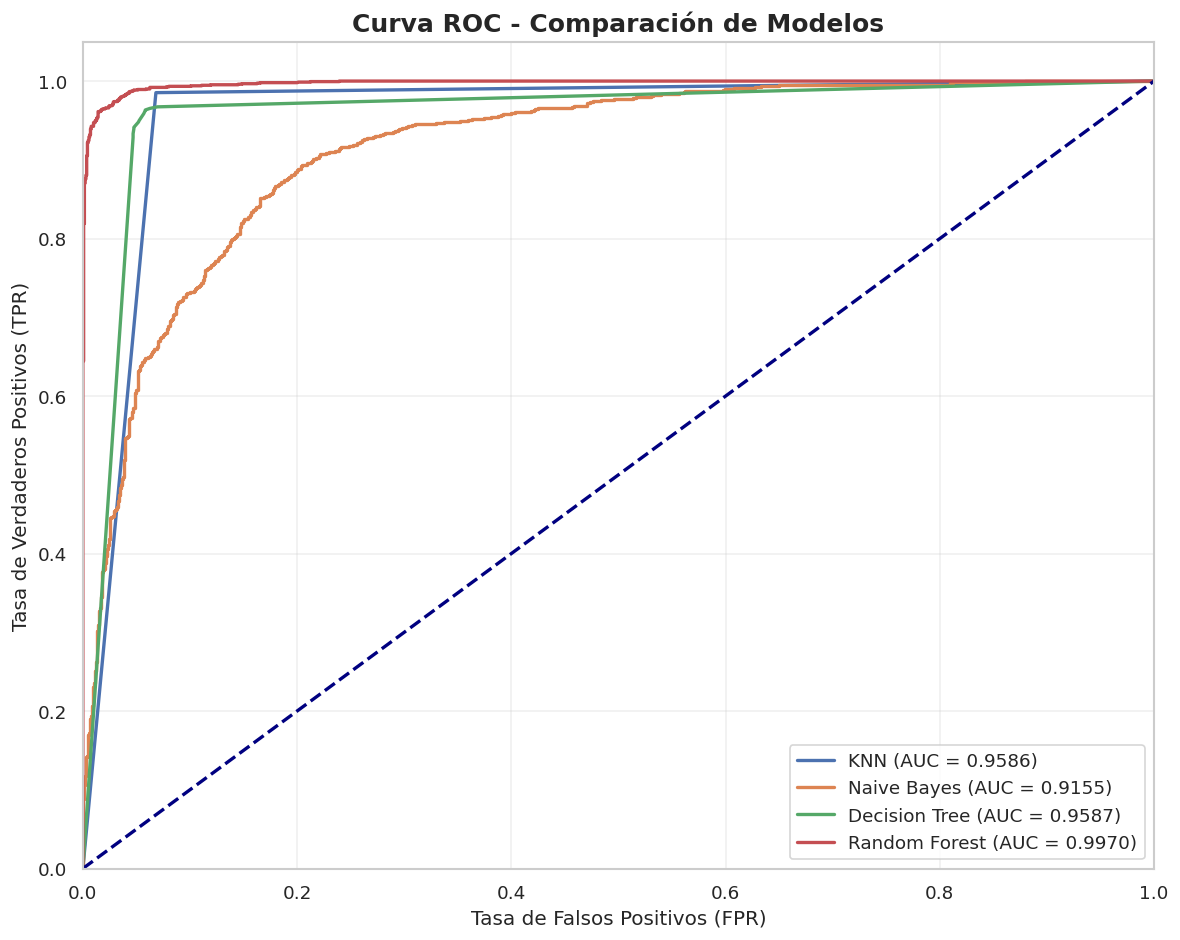

In [39]:
from sklearn.metrics import roc_curve, auc
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 8))

resumen_auc = []

for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    fpr, tpr, umbrales = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.4f})')
    
    resumen_auc.append({'Modelo': nombre, 'AUC': roc_auc})

df_auc = pd.DataFrame(resumen_auc).set_index('Modelo').sort_values('AUC', ascending=False)
display(df_auc.round(4))

ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC - Comparación de Modelos', fontsize=15, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Análisis comparativo: Curva ROC y AUC

La curva ROC evalúa la capacidad de cada modelo para distinguir correctamente entre fallas y funcionamiento normal. El AUC (área bajo la curva) resume esto en un valor, donde cuanto más cercano a 1 lo sea, mejor será la capacidad de predicción. Con los modelos:
- **Random Forest:** Es el modelo más robusto (mayor AUC). Logra una excelente tasa de detección de fallas manteniendo al mínimo los falsos positivos.
- **KNN:** Presenta un muy buen desempeño intermedio, viéndose favorecido por la estandarización previa de las variables.
- **Decision Tree:** Muestra un rendimiento inferior al random forest, con una curva más escalonada debido a sus reglas de partición estrictas.
- **Naive Bayes:** Refleja el menor poder de discriminación.

,Tiempo Entrenamiento (s),Tiempo Predicción (s)
Modelo,,
KNN,0.0125,0.0192
Naive Bayes,0.0037,0.0013
Decision Tree,0.0398,0.0012
Random Forest,3.7351,0.0758


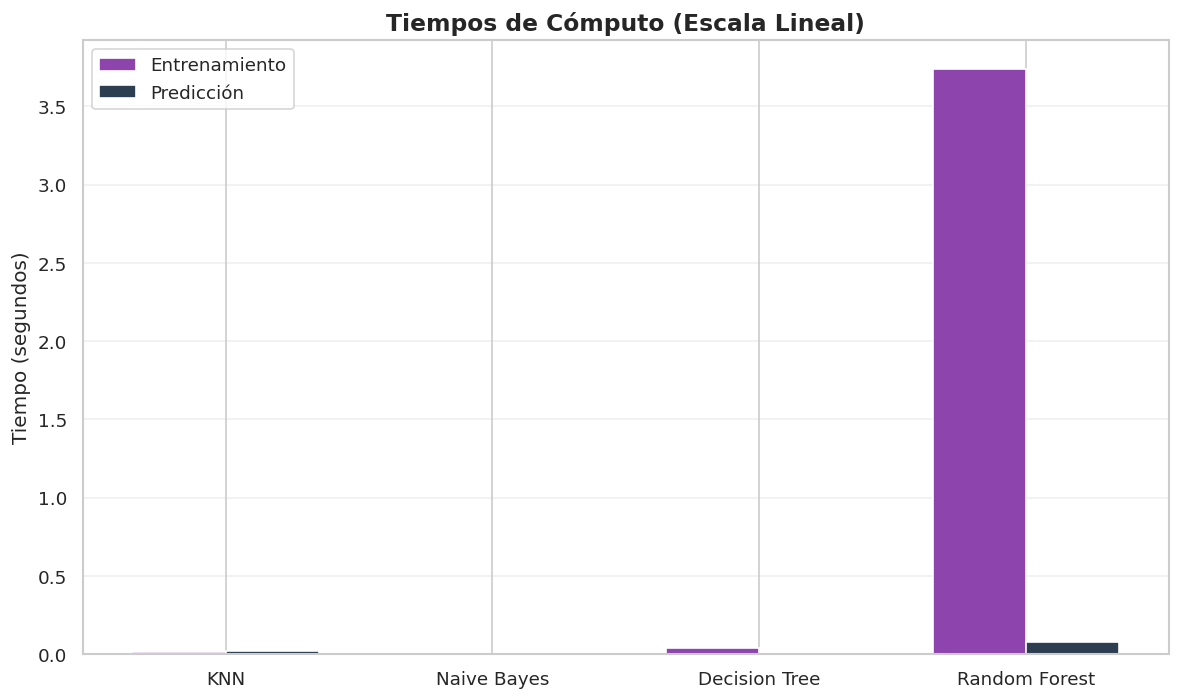

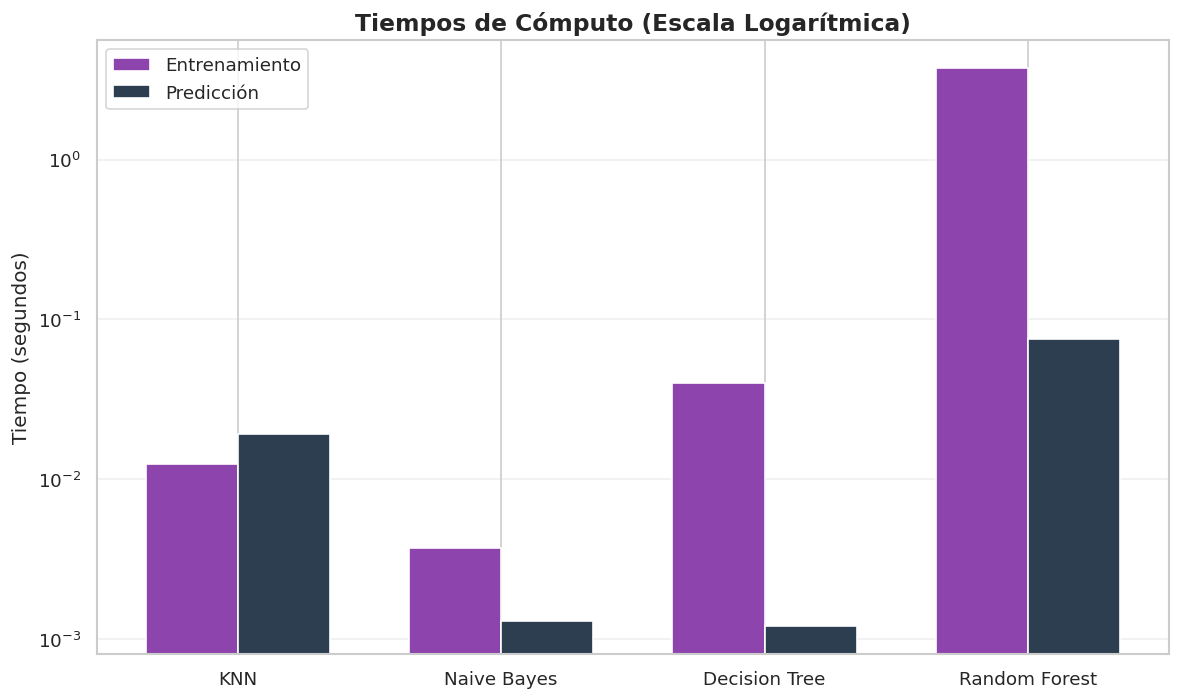

<Figure size 768x576 with 0 Axes>

In [40]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone

tiempos = []

for nombre, modelo in modelos.items():
    # Clonación del modelo para no sobreescribir el original y medir desde cero
    modelo_clonado = clone(modelo)
    
    # Medir tiempo de entrenamiento
    inicio_train = time.time()
    modelo_clonado.fit(X_train, y_train)
    fin_train = time.time()
    tiempo_train = fin_train - inicio_train
    
    # Medir tiempo de predicción
    inicio_pred = time.time()
    modelo_clonado.predict(X_test)
    fin_pred = time.time()
    tiempo_pred = fin_pred - inicio_pred
    
    tiempos.append({
        'Modelo': nombre,
        'Tiempo Entrenamiento (s)': tiempo_train,
        'Tiempo Predicción (s)': tiempo_pred
    })

df_tiempos = pd.DataFrame(tiempos).set_index('Modelo')
display(df_tiempos.round(4))

# Gráficos de Tiempos (Normal y Logarítmico)
x = np.arange(len(df_tiempos.index))
ancho = 0.35

# Gráfico 1: Escala Normal
fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(x - ancho/2, df_tiempos['Tiempo Entrenamiento (s)'], ancho, label='Entrenamiento', color='#8e44ad', edgecolor='white')
ax1.bar(x + ancho/2, df_tiempos['Tiempo Predicción (s)'], ancho, label='Predicción', color='#2c3e50', edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(df_tiempos.index, fontsize=11)
ax1.set_ylabel('Tiempo (segundos)', fontsize=12)
ax1.set_title('Tiempos de Cómputo (Escala Lineal)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico 2: Escala Logarítmica
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.bar(x - ancho/2, df_tiempos['Tiempo Entrenamiento (s)'], ancho, label='Entrenamiento', color='#8e44ad', edgecolor='white')
ax2.bar(x + ancho/2, df_tiempos['Tiempo Predicción (s)'], ancho, label='Predicción', color='#2c3e50', edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(df_tiempos.index, fontsize=11)
ax2.set_ylabel('Tiempo (segundos)', fontsize=12)
ax2.set_title('Tiempos de Cómputo (Escala Logarítmica)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()

### Análisis de Tiempos de Cómputo

Los tiempos reflejan bien las diferencias entre modelos. **Random Forest** es el más lento en entrenamiento (3.7s), pero dado que en mantenimiento predictivo se reentrenaría periódicamente, ese costo es perfectamente asumible frente a la precisión que ofrece. En predicción tampoco supone un problema real (0.076s).

Por otro lado, **Naive Bayes** y el **Árbol de Decisión** son notablemente rápidos. El árbol es el más veloz en predecir (0.001s) ya que se reduce a recorrer unas pocas reglas if-else. Sería buena opción si el sistema necesitara reaccionar en milisegundos.

**KNN** entrena rápido porque solo memoriza los datos, pero predice más lento que Naive Bayes porque debe calcular distancias contra todos los puntos al momento de clasificar.